<div style="border:solid Chocolate 2px; padding: 40px">

<b>Yaroslav, hi!👋</b>

My name is Olga Bessolitsyna, I am a mentor and I will be reviewing your project.

Please do not delete my comments, they will be especially useful for our work if the project has to be reviewed a second time. 

You can find my comments marked in <font color='green'>green</font>, <font color='gold'>yellow</font> and <font color='red'>red</font>, for example:

<br/>

<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> When the solution at a given step is completely correct.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Mentor's comment <a class="tocSkip"> </h2>
    
<b>Some remarks and recommendations💡:</b> When the solution at a given step would become even better with a few small corrections.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Mentor's comment <a class="tocSkip"></h2>

    
<b>Needs revision🤔:</b>
 When the solution at a given step requires substantial rework and corrections. A reminder: the project cannot be accepted on the first attempt if the review contains comments recommending that steps be reworked.
</div>

# Churn prediction for the telecom operator "TeleDom"

The operator wants to spot subscribers who are about to terminate their contract in advance. Using data on contracts, customers and services, I build a model that predicts churn. Stack: pandas, scikit-learn pipelines, Optuna, phik. The metric is ROC-AUC, with a target test value of no less than 0.85

## 1. Environment setup

A single cell installs the packages and defines the constants. Computation runs on the CPU

In [1]:
%pip install -q catboost phik optuna optuna-integration shap skimpy

import os
import random
import time
import urllib.request
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import phik
import seaborn as sns
import shap

from catboost import CatBoostClassifier, Pool
from optuna.distributions import CategoricalDistribution, FloatDistribution, IntDistribution
from optuna_integration import OptunaSearchCV
from skimpy import clean_columns
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import (StratifiedKFold, cross_val_predict, cross_val_score,
                                     train_test_split)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sqlalchemy import create_engine, inspect

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 310726
DB_URL = 'https://code.s3.yandex.net/data-scientist/ds-plus-final.db'
DATA_SNAPSHOT = pd.Timestamp('2020-02-01')

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

RANDOM_STATE

[praktikum-paths] active: 64 data files + 71 dirs indexed from 7 Praktikum repos; /datasets, C:\ and .\ literals resolve to local copies



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: /home/aiagent/.venvs/gradproj/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


310726

## 2. Loading the data

In [2]:
db_candidates = ['ds-plus-final.db', 'graduation_project/ds-plus-final.db', '/datasets/ds-plus-final.db']
path_to_db = next((candidate for candidate in db_candidates if os.path.exists(candidate)), db_candidates[0])

if not os.path.exists(path_to_db):
    urllib.request.urlretrieve(DB_URL, path_to_db)

path_to_db

'/datasets/ds-plus-final.db'

I connect to the database and look at which tables it holds

In [3]:
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)
db_tables = inspect(engine).get_table_names()

pd.Series(db_tables, name='table').to_frame()

,table
0,contract
1,data_arc
2,data_bulk
3,data_bulk_time
4,data_gas
5,data_temp
6,data_wire
7,data_wire_time
8,internet
9,personal


There turned out to be more than four tables, so I will load only the ones the project needs

In [4]:
required_tables = ['contract', 'personal', 'internet', 'phone']
missing_tables = sorted(set(required_tables) - set(db_tables))
foreign_tables = sorted(set(db_tables) - set(required_tables))

## 3. First look at the source tables

I load all four tables into memory and inspect them as they are, to see what format the data arrived in from the database

In [5]:
tables = {name: pd.read_sql(f'SELECT * FROM {name}', engine) for name in required_tables}

contract = tables['contract']
personal = tables['personal']
internet = tables['internet']
phone = tables['phone']

pd.DataFrame({name: df.shape for name, df in tables.items()}, index=['rows', 'columns']).T

,rows,columns
contract,7043,8
personal,7043,5
internet,5517,8
phone,6361,2


### 3.1 The `contract` table

Contracts: service start and end dates, payment type and payment amounts

In [6]:
display(contract.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


In [7]:
contract.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   str  
 1   BeginDate         7043 non-null   str  
 2   EndDate           7043 non-null   str  
 3   Type              7043 non-null   str  
 4   PaperlessBilling  7043 non-null   str  
 5   PaymentMethod     7043 non-null   str  
 6   MonthlyCharges    7043 non-null   str  
 7   TotalCharges      7043 non-null   str  
dtypes: str(8)
memory usage: 897.1 KB


The data types need to be converted

In [8]:
display(contract.describe(include='all').T)

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
BeginDate,7043,77,2014-02-01,366
EndDate,7043,67,No,5942
Type,7043,3,Month-to-month,3875
PaperlessBilling,7043,2,Yes,4171
PaymentMethod,7043,4,Electronic check,2365
MonthlyCharges,7043,1585,20.05,61
TotalCharges,7043,6658,,11


### 3.2 The `personal` table

Personal customer data: gender, senior citizen flag, presence of a partner and dependents

In [9]:
display(personal.head())

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [10]:
personal.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   str  
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: str(5)
memory usage: 418.1 KB


The data types need to be converted

In [11]:
display(personal.describe(include='all').T)

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933


### 3.3 The `internet` table

Internet services: connection type and six additional services

In [12]:
display(internet.head())

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [13]:
internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        5517 non-null   str  
 1   InternetService   5517 non-null   str  
 2   OnlineSecurity    5517 non-null   str  
 3   OnlineBackup      5517 non-null   str  
 4   DeviceProtection  5517 non-null   str  
 5   TechSupport       5517 non-null   str  
 6   StreamingTV       5517 non-null   str  
 7   StreamingMovies   5517 non-null   str  
dtypes: str(8)
memory usage: 517.8 KB


The data types need to be converted

In [14]:
display(internet.describe(include='all').T)

,count,unique,top,freq
customerID,5517,5517,7590-VHVEG,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785


The most popular services are the ones related to media content. The least popular is tech support

### 3.4 The `phone` table

Telephony: connection of multiple lines

In [15]:
display(phone.head())

,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [16]:
phone.info()

<class 'pandas.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerId     6361 non-null   str  
 1   MultipleLines  6361 non-null   str  
dtypes: str(2)
memory usage: 177.0 KB


The data types need to be converted

In [17]:
display(phone.describe(include='all').T)

,count,unique,top,freq
CustomerId,6361,6361,5575-GNVDE,1
MultipleLines,6361,2,No,3390


<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> the data has been loaded correctly

I gather into a single table everything that has to be checked before merging. Next I will check what the ID column is called, how many missing values there are, and whether there are full duplicate rows and repeated customer IDs

In [18]:
pd.DataFrame([
    {
        'table': name,
        'ID column': df.columns[0],
        'missing': int(df.isna().sum().sum()),
        'duplicate rows': int(df.duplicated().sum()),
        'duplicate IDs': int(df[df.columns[0]].duplicated().sum()),
    }
    for name, df in tables.items()
]).set_index('table')

,ID column,missing,duplicate rows,duplicate IDs
table,,,,
contract,customerID,0,0,0
personal,customerID,0,0,0
internet,customerID,0,0,0
phone,CustomerId,0,0,0


I check the keys explicitly, before merging: whether the customer lists in `contract` and `personal` match, and whether the service records really are subsets of the contracts. If any "extra" IDs turn up, the merge will silently lose part of the customers

In [19]:
contract_ids = set(contract['customerID'])

pd.Series({
    'clients in contract': len(contract_ids),
    'personal IDs missing from contract': len(set(personal['customerID']) - contract_ids),
    'contract IDs missing from personal': len(contract_ids - set(personal['customerID'])),
    'internet IDs missing from contract': len(set(internet['customerID']) - contract_ids),
    'phone IDs missing from contract': len(set(phone['CustomerId']) - contract_ids),
    'clients without internet or phone': len(contract_ids - set(internet['customerID']) - set(phone['CustomerId'])),
}, name='value').to_frame()

,value
clients in contract,7043
personal IDs missing from contract,0
contract IDs missing from personal,0
internet IDs missing from contract,0
phone IDs missing from contract,0
clients without internet or phone,0


At the same time I check what will later have to be cast to proper types: whether the dates parse without loss and whether they really are monthly (all on the first day of the month), and then how many placeholder rows with a single space there are in the payment amounts

In [20]:
begin_dates = pd.to_datetime(contract['BeginDate'], errors='coerce')
end_dates = pd.to_datetime(contract.loc[contract['EndDate'] != 'No', 'EndDate'], errors='coerce')

pd.Series({
    'BeginDate not parsed as a date': int(begin_dates.isna().sum()),
    'EndDate not parsed as a date': int(end_dates.isna().sum()),
    'start dates not on the 1st': int((begin_dates.dt.day != 1).sum()),
    'termination dates not on the 1st': int((end_dates.dt.day != 1).sum()),
}, name='value').to_frame()

,value
BeginDate not parsed as a date,0
EndDate not parsed as a date,0
start dates not on the 1st,0
termination dates not on the 1st,0


In [21]:
pd.Series({
    'TotalCharges is a single space': int((contract['TotalCharges'] == ' ').sum()),
    'TotalCharges not convertible to a number': int(pd.to_numeric(contract['TotalCharges'], errors='coerce').isna().sum()),
    'MonthlyCharges not convertible to a number': int(pd.to_numeric(contract['MonthlyCharges'], errors='coerce').isna().sum()),
}, name='value').to_frame()

,value
TotalCharges is a single space,11
TotalCharges not convertible to a number,11
MonthlyCharges not convertible to a number,0


**Interim conclusion for this section**

- `contract` has 7043 rows, `personal` 7043, `internet` 5517, `phone` 6361. In `EndDate`, 5942 customers have `No` and 1101 have a termination date
- Everything arrived as text: I will cast the payments to numbers, the dates to `datetime` and the `Yes`/`No` answers to `bool` flags
- The dates parse without loss and all of them fall on the first day of the month, so the contract lifetime can be counted in months
- 11 rows in `TotalCharges` contain a single space `' '`, which is why `isna()` does not see them
- There are no duplicates, neither by row nor by ID, and the tables join one to one. The key in `phone` is called `CustomerId`, I will rename it
- The differing row counts are not lost data but customers without one of the services. Missing values after the merge should be read as "the service is not connected"

<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> good

## 4. Preprocessing the source tables

I convert the column names to snake_case, cast the types to suitable ones and look for anomalies. I do not fill the missing values in `total_charges` yet

I convert the column names to snake_case with the `clean_columns` function from `skimpy`. From here on the names follow a single style, and in `phone` this also fixes the `CustomerId` key

In [22]:
tables = {name: clean_columns(frame) for name, frame in tables.items()}

contract = tables['contract']
personal = tables['personal']
internet = tables['internet']
phone = tables['phone']

display(pd.Series({name: ', '.join(frame.columns) for name, frame in tables.items()},
                  name='columns').to_frame())

pd.Series({name: [column for column in frame.columns if column != column.lower()]
           for name, frame in tables.items()},
          name='still not in snake_case', dtype=object).to_frame()

,columns
contract,"customer_id, begin_date, end_date, type, paper..."
personal,"customer_id, gender, senior_citizen, partner, ..."
internet,"customer_id, internet_service, online_security..."
phone,"customer_id, multiple_lines"


,still not in snake_case
contract,[]
personal,[]
internet,[]
phone,[]


<div class="alert alert-warning">
    <h2> Mentor's comment <a class="tocSkip"> </h2>
    
<b>Some remarks and recommendations💡:</b>
there is a rather good library for routine  pandas operations - https://pypi.org/project/skimpy/. It also has a clean_column() function that converts column names to the appropriate form in one step.
       
I recommend taking a look.

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Student's comment</b></font>
I rewrote the name conversion using clean_columns from skimpy and removed the manual dictionary of 21 pairs. The result matched column for column.
</div>

<div class="alert alert-block alert-danger">
<h2> Mentor's comment <a class="tocSkip"></h2>

    
<b>Needs revision🤔:</b> it is better to delete after the analysis; right now it is unclear on what grounds the deletion is made - there are no statistics, no plots, no correlation. You need either to justify it here (not. with words only) or to move it after the analysis

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Student's comment</b></font>
I moved the deletion out of section 4 into the new subsection 6.3, after the correlation analysis

In `contract` I convert the dates to `datetime`, both payment columns to numbers, the eleven spaces in `total_charges` become `NaN`, and `paperless_billing` becomes `bool`. I leave `end_date` as text: I will build the target from it during the merge

In [23]:
contract['begin_date'] = pd.to_datetime(contract['begin_date'])
contract['monthly_charges'] = contract['monthly_charges'].astype(float)
contract['total_charges'] = pd.to_numeric(contract['total_charges'], errors='coerce')
contract['paperless_billing'] = contract['paperless_billing'].eq('Yes')

display(contract.dtypes.to_frame('type'))
display(pd.Series({
    'missing in begin_date': int(contract['begin_date'].isna().sum()),
    'missing in monthly_charges': int(contract['monthly_charges'].isna().sum()),
    'missing in total_charges': int(contract['total_charges'].isna().sum()),
}, name='value').to_frame())

,type
customer_id,str
begin_date,datetime64[us]
end_date,str
type,str
paperless_billing,bool
payment_method,str
monthly_charges,float64
total_charges,float64


,value
missing in begin_date,0
missing in monthly_charges,0
missing in total_charges,11


In `personal` I convert three features to `bool`: `senior_citizen` with values 0 and 1, `partner` and `dependents`. `gender` stays a text category

In [24]:
personal['senior_citizen'] = personal['senior_citizen'].eq('1')
personal['partner'] = personal['partner'].eq('Yes')
personal['dependents'] = personal['dependents'].eq('Yes')

display(personal.dtypes.to_frame('type'))
display(personal.head())

,type
customer_id,str
gender,str
senior_citizen,bool
partner,bool
dependents,bool


,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,False,True,False
1,5575-GNVDE,Male,False,False,False
2,3668-QPYBK,Male,False,False,False
3,7795-CFOCW,Male,False,False,False
4,9237-HQITU,Female,False,False,False


In `internet` I convert the six additional services to `bool` as a single list, which will come in handy later as well

In [25]:
internet_addons = ['online_security', 'online_backup', 'device_protection', 'tech_support',
                   'streaming_tv', 'streaming_movies']

internet[internet_addons] = internet[internet_addons].eq('Yes')

internet.dtypes.to_frame('type')

,type
customer_id,str
internet_service,str
online_security,bool
online_backup,bool
device_protection,bool
tech_support,bool
streaming_tv,bool
streaming_movies,bool


I convert the table's only service, `multiple_lines`, to `bool`

In [26]:
phone['multiple_lines'] = phone['multiple_lines'].eq('Yes')

phone.dtypes.to_frame('type')

,type
customer_id,str
multiple_lines,bool


The payments are numbers now, so descriptive statistics for them finally make sense

In [27]:
contract.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
monthly_charges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.8500,118.75
total_charges,7032.0,2118.621822,2112.736199,19.05,439.745,1345.275,3239.3175,9221.38


Next I look for anomalies that matter specifically in telecom. First I check whether there are any negative or zero payments. For a telecom operator such a subscriber is probably either an export error or an internal service contract. Then I look into who these eleven customers with a missing payment total are. According to the task statement the data is current as of February 1, 2020, and I expect all the missing values to fall exactly on contracts signed on the snapshot date. Such subscribers, most likely, simply have not received their first bill yet

In [28]:
pd.Series({
    'monthly_charges negative': int((contract['monthly_charges'] < 0).sum()),
    'monthly_charges zero': int((contract['monthly_charges'] == 0).sum()),
    'total_charges negative': int((contract['total_charges'] < 0).sum()),
    'total_charges zero': int((contract['total_charges'] == 0).sum()),
    'contracts in total': len(contract),
}, name='value').to_frame()

,value
monthly_charges negative,0
monthly_charges zero,0
total_charges negative,0
total_charges zero,0
contracts in total,7043


In [29]:
missing_total = contract['total_charges'].isna()
started_at_snapshot = contract['begin_date'] == DATA_SNAPSHOT

pd.Series({
    'missing in total_charges': int(missing_total.sum()),
    'contracts started 2020-02-01': int(started_at_snapshot.sum()),
    'missing among those contracts': int((missing_total & started_at_snapshot).sum()),
    'missing with an earlier start date': int((missing_total & ~started_at_snapshot).sum()),
    'missing for terminated contracts': int((missing_total & (contract['end_date'] != 'No')).sum()),
}, name='value').to_frame()

,value
missing in total_charges,11
contracts started 2020-02-01,11
missing among those contracts,11
missing with an earlier start date,0
missing for terminated contracts,0


Does the accumulated amount agree with the contract duration? I count how many months a customer was served, from the start date to termination, and for active contracts up to the February 1, 2020 snapshot, and multiply that by the monthly payment. The estimate is deliberately rough, it accounts for neither a tariff change nor services connected mid-term, so I treat it as an order-of-magnitude check

In [30]:
billed_until = pd.to_datetime(contract['end_date'].where(contract['end_date'] != 'No')).fillna(DATA_SNAPSHOT)
months_served = ((billed_until.dt.year - contract['begin_date'].dt.year) * 12
                 + (billed_until.dt.month - contract['begin_date'].dt.month))
rough_total = months_served * contract['monthly_charges']

months_served.describe().to_frame('months of service')

,months of service
count,7043.000000
mean,29.495385
std,22.446726
min,0.000000
25%,9.000000
50%,25.000000
75%,48.000000
max,76.000000


In [31]:
charges_ratio = (contract['total_charges'] / rough_total).dropna()
deviation_percent = 100 * (charges_ratio - 1).abs()

display(charges_ratio.describe().round(3).to_frame('total_charges vs rough estimate'))
display(pd.DataFrame({
    'clients': [int((deviation_percent > level).sum()) for level in [5, 10, 20]],
    'share, %': [round(100 * (deviation_percent > level).mean(), 1) for level in [5, 10, 20]],
}, index=['deviation above 5%', 'deviation above 10%', 'deviation above 20%']))

,total_charges vs rough estimate
count,7032.000
mean,1.028
std,0.034
min,1.000
25%,1.000
50%,1.010
75%,1.060
max,1.100


,clients,"share, %"
deviation above 5%,2003,28.5
deviation above 10%,252,3.6
deviation above 20%,0,0.0


**Interim conclusion for this section**

- The column names were converted to snake_case with a single `clean_columns` call from `skimpy`, and the key in `phone` was fixed along the way
- The types were cast to working ones, `end_date` stayed text
- There are no negative or zero payments
- The 11 missing values in `total_charges` are new customers. All of them fall on contracts started on February 1, 2020, the snapshot date, and all of them are active
- The accumulated amount is consistent with the duration. The ratio of `total_charges` to the "months x monthly payment" estimate lies between 1.000 and 1.100 with a median of 1.010, and not a single customer deviates by more than 20%. There are no anomalies, I remove no one

<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> I agree

## 5. Merging the tables and building the target

I combine the four tables into one with a row per customer: I close the question of the missing values in `total_charges`, join on `customer_id`, record the `has_internet` flag, fill in the missing values for services that are not connected, extract the target and add both duration features

I return to the eleven customers with a missing payment total. Section 4 shows that this is not corrupted data: all eleven signed their contract on February 1, 2020, the snapshot date, and have not received their first bill yet. Filling the gap with zero is formally possible, but such a row describes nothing except the fact that data on the customer has not accumulated yet: zero total charges, zero contract lifetime and a status known in advance, since the customer physically had no time to leave. There is no benefit in this for the model, so I delete the rows, all the more so as this is only 0.16% of the sample

In [32]:
contracts_before = len(contract)
contract = contract.dropna(subset=['total_charges']).reset_index(drop=True)

pd.Series({
    'contracts before removal': contracts_before,
    'rows removed': contracts_before - len(contract),
    'contracts remaining': len(contract),
    'missing in total_charges': int(contract['total_charges'].isna().sum()),
}, name='value').to_frame()

,value
contracts before removal,7043
rows removed,11
contracts remaining,7032
missing in total_charges,0


I build the table step by step rather than in a single expression. After each join I want to see that the size of the table has not drifted

In [33]:
data = contract.merge(personal, on='customer_id', how='left', validate='one_to_one')

pd.Series({
    'rows': len(data),
    'columns': data.shape[1],
    'unique clients': data['customer_id'].nunique(),
    'missing in the table': int(data.isna().sum().sum()),
}, name='after personal').to_frame()

,after personal
rows,7032
columns,12
unique clients,7032
missing in the table,0


Next come the internet services. There are fewer records in `internet` than there are customers, so the number of rows should stay the same

In [34]:
data = data.merge(internet, on='customer_id', how='left', validate='one_to_one')

pd.Series({
    'rows': len(data),
    'columns': data.shape[1],
    'unique clients': data['customer_id'].nunique(),
    'missing in the table': int(data.isna().sum().sum()),
}, name='after internet').to_frame()

,after internet
rows,7032
columns,19
unique clients,7032
missing in the table,10640


Telephony, the last services column

In [35]:
data = data.merge(phone, on='customer_id', how='left', validate='one_to_one')

pd.Series({
    'rows': len(data),
    'columns': data.shape[1],
    'unique clients': data['customer_id'].nunique(),
    'missing in the table': int(data.isna().sum().sum()),
}, name='after phone').to_frame()

,after phone
rows,7032
columns,20
unique clients,7032
missing in the table,11320


<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> the unified dataset has been assembled correctly

I count the missing values across the service columns and assemble a list of the seven columns that are stored as flags. Here I also record the `has_internet` flag: the customer is present in the `internet` table

In [36]:
addon_columns = internet_addons + ['multiple_lines']
data['has_internet'] = data['online_security'].notna()

display(data[addon_columns].isna().sum().to_frame('missing'))
display(pd.Series({
    'clients without internet': int((~data['has_internet']).sum()),
    'clients without phone': int(data['multiple_lines'].isna().sum()),
    'missing in the whole table': int(data.isna().sum().sum()),
}, name='value').to_frame())

,missing
online_security,1520
online_backup,1520
device_protection,1520
tech_support,1520
streaming_tv,1520
streaming_movies,1520
multiple_lines,680


,value
clients without internet,1520
clients without phone,680
missing in the whole table,11320


I fill the missing values with `False`: here this means not "unknown" but "the service is not connected". I give the columns back their `bool` type. In `internet_service` a missing value means the same thing, so I set `No`. The `has_internet` flag was recorded before the filling, otherwise it would have dissolved into the zeros

In [37]:
data[addon_columns] = data[addon_columns].fillna(False).astype(bool)
data['internet_service'] = data['internet_service'].fillna('No')

display(data['has_internet'].value_counts().to_frame('clients'))
display(data['multiple_lines'].value_counts().to_frame('clients'))

int(data.isna().sum().sum())

,clients
has_internet,
True,5512
False,1520


,clients
multiple_lines,
False,4065
True,2967


0

I extract the target. In `end_date` active customers have `No`, while those who left have a termination date, so the mere presence of a date is the answer. `churn` is `True` if the contract has been terminated and `False` if the customer is still with the operator

In [38]:
data['churn'] = data['end_date'] != 'No'

churn_stats = pd.concat([
    data['churn'].value_counts().rename('clients'),
    data['churn'].value_counts(normalize=True).mul(100).round(1).rename('share, %'),
], axis=1).rename(index={False: 'stayed', True: 'churned'})

churn_stats

,clients,"share, %"
churn,,
stayed,5931,84.3
churned,1101,15.7


<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b>the target has been extracted correctly

I add a contract duration feature. I compute it the same way I computed the service period in section 4: for churned customers from the contract start date to the termination date, for active ones up to the February 1, 2020 snapshot. I take the difference in whole months, and this is correct because in section 3 I verified that all dates in the data fall on the first day of the month

In [39]:
contract_end = pd.to_datetime(data['end_date'].where(data['end_date'] != 'No')).fillna(DATA_SNAPSHOT)
data['contract_duration'] = ((contract_end.dt.year - data['begin_date'].dt.year) * 12
                             + (contract_end.dt.month - data['begin_date'].dt.month))

data['contract_duration'].describe().to_frame('contract duration, months')

,"contract duration, months"
count,7032.000000
mean,29.541524
std,22.433916
min,1.000000
25%,9.000000
50%,25.000000
75%,48.000000
max,76.000000


For churned customers `contract_duration` is computed from the actual `end_date`, the very field `churn` was built from. The project specification permits such a feature, but the offline estimate based on it is optimistic

Hence the rule for assembling features. `begin_date` and `end_date` never make it into `X`, and of their derivatives only those named explicitly are allowed, no more than one. Otherwise the churn date can be recovered arithmetically from the pair "start date + duration". I assemble the feature list by explicit enumeration in section 8

I add a second time feature, `life_span`, the customer's lifetime in days. For churned customers up to the termination date, for active ones up to the February 1, 2020 snapshot. Unlike months, the daily scale distinguishes customers within the same month, so it is the one that goes into the feature matrix, while `contract_duration` stays for exploratory analysis

**The price of this feature.** For churned customers the period is counted up to `end_date`, from which `churn` was built, while for active ones the boundary is the same for everyone. The number of days therefore hints at whether the end of the period falls on the snapshot date, and that is precisely the answer. All metrics below are optimistic by that amount

<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> I agree

In [40]:
data['life_span'] = (contract_end - data['begin_date']).dt.days

display(data['life_span'].describe().round(1).to_frame('customer lifetime, days'))

data[['begin_date', 'end_date', 'contract_duration', 'life_span']].head()

,"customer lifetime, days"
count,7032.0
mean,900.0
std,682.7
min,28.0
25%,276.0
50%,761.0
75%,1461.0
max,2314.0


,begin_date,end_date,contract_duration,life_span
0,2020-01-01,No,1,31
1,2017-04-01,No,34,1036
2,2019-10-01,No,4,123
3,2016-05-01,No,45,1371
4,2019-09-01,No,5,153


I look at the assembled table as a whole

In [41]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7032 non-null   str           
 1   begin_date         7032 non-null   datetime64[us]
 2   end_date           7032 non-null   str           
 3   type               7032 non-null   str           
 4   paperless_billing  7032 non-null   bool          
 5   payment_method     7032 non-null   str           
 6   monthly_charges    7032 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   gender             7032 non-null   str           
 9   senior_citizen     7032 non-null   bool          
 10  partner            7032 non-null   bool          
 11  dependents         7032 non-null   bool          
 12  internet_service   7032 non-null   str           
 13  online_security    7032 non-null   bool          
 14  online_backup      

In [42]:
display(data.head())

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,has_internet,churn,contract_duration,life_span
0,7590-VHVEG,2020-01-01,No,Month-to-month,True,Electronic check,29.85,31.04,Female,False,...,True,False,False,False,False,False,True,False,1,31
1,5575-GNVDE,2017-04-01,No,One year,False,Mailed check,56.95,2071.84,Male,False,...,False,True,False,False,False,False,True,False,34,1036
2,3668-QPYBK,2019-10-01,No,Month-to-month,True,Mailed check,53.85,226.17,Male,False,...,True,False,False,False,False,False,True,False,4,123
3,7795-CFOCW,2016-05-01,No,One year,False,Bank transfer (automatic),42.30,1960.60,Male,False,...,False,True,True,False,False,False,True,False,45,1371
4,9237-HQITU,2019-09-01,No,Month-to-month,True,Electronic check,70.70,353.50,Female,False,...,False,False,False,False,False,False,True,False,5,153


**Interim conclusion for this section**

- The table has 7032 rows and 24 columns, with not a single missing value. The eleven newcomers without statistics were removed, which is 0.16% of the sample
- The three `merge` calls with `validate='one_to_one'` went through without errors, the service gaps were closed with `False`, and the `has_internet` flag was recorded before the filling
- The classes are imbalanced. 1101 customers left, 15.7%, and 5931 stayed, 84.3%. This means `stratify` and class weighting are needed, and that the metric is ROC-AUC rather than accuracy
- `contract_duration` was created. Median 25 months, range from 1 to 76. `life_span` is the same period in days. Median 761, range from 28 to 2314
- Both duration features are retrospective, the daily scale more so. Other derivatives of `begin_date` will not go into `X`

## 6. Correlation analysis and candidate new features

The features are of mixed types, so the Pearson coefficient is not suitable. I take phik. It measures the association of any pair on a scale from 0 to 1, bins the numeric columns itself, and the coefficient has no sign

### 6.1 Correlation matrix

I compute the matrix without `customer_id` and the two dates. `churn` was built from `end_date`, so the association would be redundant. I declare `monthly_charges`, `total_charges`, `contract_duration` and `life_span` to be interval variables

In [43]:
correlation_columns = data.columns.drop(['customer_id', 'begin_date', 'end_date'])
interval_columns = ['monthly_charges', 'total_charges', 'contract_duration', 'life_span']

phik_matrix = data[correlation_columns].phik_matrix(interval_cols=interval_columns)

phik_matrix.shape

(21, 21)

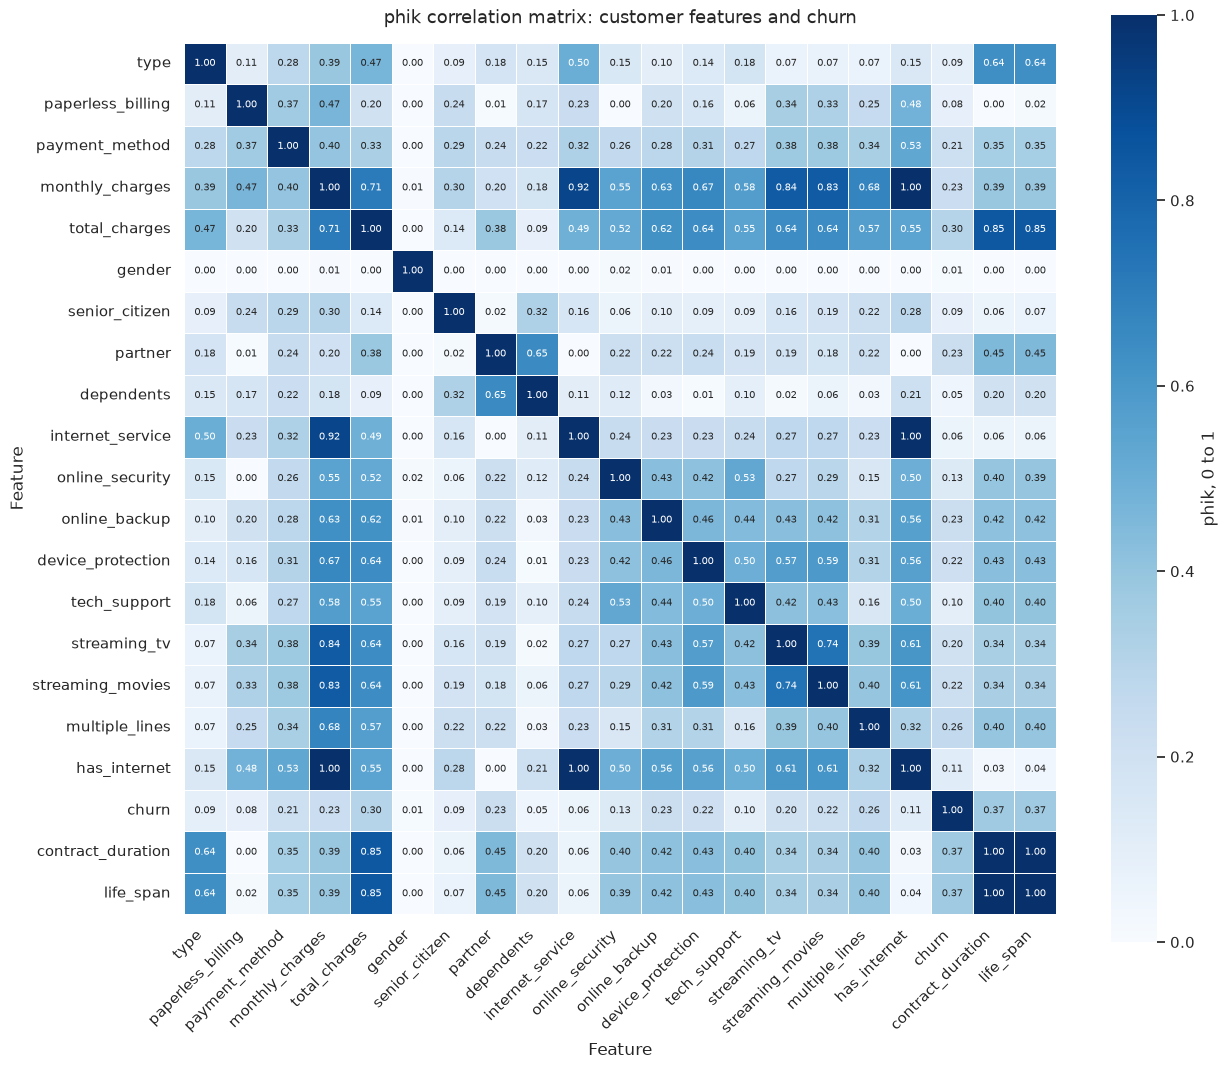

In [44]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', annot_kws={'size': 7}, cmap='Blues',
            vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'phik, 0 to 1'}, ax=ax)
ax.set_title('phik correlation matrix: customer features and churn', fontsize=13, pad=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Feature')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

I write out the strongest pairs, leaving `churn` out of them

In [45]:
feature_matrix = phik_matrix.drop(index='churn', columns='churn')
upper_triangle = np.triu(np.ones(feature_matrix.shape, dtype=bool), k=1)
feature_pairs = (feature_matrix.where(upper_triangle).stack().dropna()
                 .rename_axis(['feature 1', 'feature 2']).sort_values(ascending=False))

display(feature_pairs.head(15).round(3).to_frame('phik'))

len(feature_pairs)

phik
feature 1         feature 2               
internet_service  has_internet       1.000
contract_duration life_span          1.000
monthly_charges   has_internet       0.999
                  internet_service   0.919
total_charges     life_span          0.848
                  contract_duration  0.847
monthly_charges   streaming_tv       0.836
                  streaming_movies   0.833
streaming_tv      streaming_movies   0.743
monthly_charges   total_charges      0.711
                  multiple_lines     0.677
                  device_protection  0.668
partner           dependents         0.652
total_charges     streaming_movies   0.644
                  streaming_tv       0.643

190

The strongest associations are not with the target but among the features themselves.

- **There are two pairs with a value of 1.000.** `internet_service` with `has_internet`: the flag is derived from the type, so phik is maximal. `life_span` with `contract_duration`: the same period in days and in months, and within the bins phik sees them as identical
- **The connection flag almost coincides with the payment.** `monthly_charges` with `has_internet` 0.999 and with `internet_service` 0.919; without internet the bill runs into the lower edge of the scale
- **Billing closes the money block.** `total_charges` with `life_span` 0.848 and with `contract_duration` 0.847, then the payment with `streaming_tv` 0.836 and with `streaming_movies` 0.833
- **The family features duplicate each other,** `partner` with `dependents` 0.652

The multicollinearity is pronounced. I will read feature importance in groups, and I filter out the duplicates and weak features in 6.3

### 6.2 Association of the features with churn

In [46]:
churn_correlation = phik_matrix['churn'].drop('churn').sort_values(ascending=False)

churn_correlation.round(3).to_frame('phik with churn')

,phik with churn
life_span,0.374
contract_duration,0.371
total_charges,0.304
multiple_lines,0.261
online_backup,0.230
partner,0.228
monthly_charges,0.225
streaming_movies,0.222
device_protection,0.219
payment_method,0.214


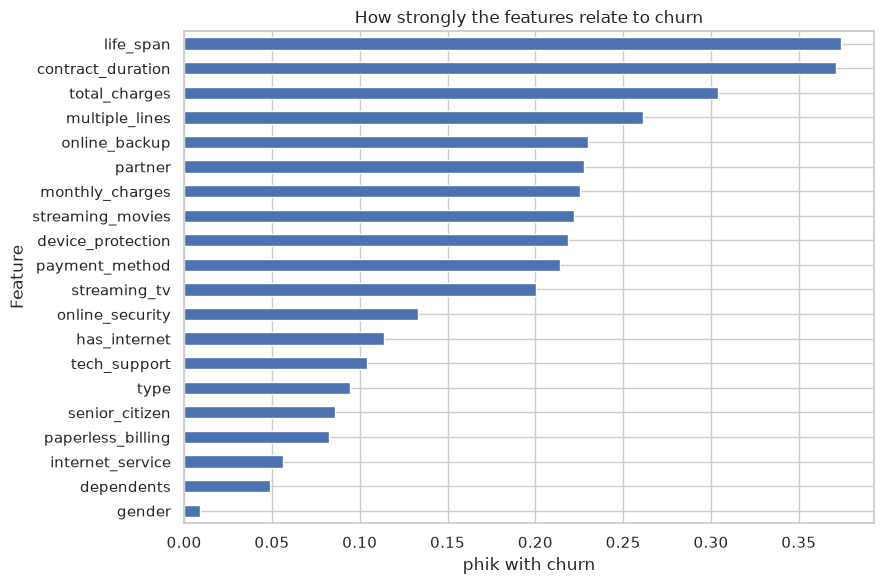

In [47]:
fig, ax = plt.subplots(figsize=(9, 6))
churn_correlation.sort_values().plot.barh(ax=ax, color='#4C72B0')
ax.set_title('How strongly the features relate to churn')
ax.set_xlabel('phik with churn')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

There is not a single strong association with the target, the maximum across the table is 0.374.

- **The top of the list is held by the duration features.** `life_span` 0.374, `contract_duration` 0.371, `total_charges` 0.304. This should be read with caution: for churned customers the period is counted up to the termination date. The daily scale beats the monthly one by a mere 0.003
- **Services and payments sit in a narrow corridor of 0.20–0.26,** the best being `multiple_lines` at 0.261
- **The bottom of the list:** `type` 0.095, `senior_citizen` 0.086, `paperless_billing` 0.083, and right at the very bottom `internet_service` 0.056, `dependents` 0.049 and `gender` 0.009. These three I examine in 6.3

Churn is not explained by a single factor; quality will come from adding up weak signals, that is, from ensemble models

<div class="alert alert-success">
<h2> Mentor's comment<a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> Excellent, everything is correct. For the future, some useful links - checking feature importance with a model is only one of the possible approaches (correlation among them). Analytical hypothesis-testing methods are used as well. 

There are several tools for feature selection, you can read more about them in this article (Feature selection in machine learning tasks): https://habr.com/ru/post/550978/

The sklearn library has the methods mutual_info_regression and mutual_info_classif for regression and classification respectively.
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#sklearn.feature_selection.mutual_info_classif

### 6.3 Filtering out features

Three features stand at the very bottom of the list of associations with churn. Before removing them I check them with numbers: the association with the target, the spread of the churn share across categories, and the strongest association with a feature that stays

In [48]:
dropped_features = ['internet_service', 'dependents', 'gender']
kept_features = phik_matrix.columns.drop(dropped_features + ['churn'])
churn_rates = {feature: 100 * data.groupby(feature)['churn'].mean() for feature in dropped_features}

pd.DataFrame([
    {'feature': feature,
     'phik with churn': phik_matrix.loc[feature, 'churn'],
     'churn-rate spread, pp': rates.max() - rates.min(),
     'nearest retained': phik_matrix.loc[feature, kept_features].idxmax(),
     'phik with it': phik_matrix.loc[feature, kept_features].max()}
    for feature, rates in churn_rates.items()
]).set_index('feature').round(3)

,phik with churn,"churn-rate spread, pp",nearest retained,phik with it
feature,,,,
internet_service,0.056,8.692,has_internet,1.000
dependents,0.049,2.673,partner,0.652
gender,0.009,0.986,online_security,0.017


- **`internet_service` and `has_internet` are associated one way only,** phik 1.000: the flag is derived from the type, but the type cannot be recovered back from the flag. The type's association with churn is lower, 0.056 against 0.114 for the flag. Of the 8.7 pp spread (DSL 14.3%, Fiber optic 19.2%, no internet 10.5%) the flag holds 6.5 pp, and the difference between DSL and fiber is lost. I keep the flag in the set
- **`dependents` almost repeats `partner`,** phik 0.652 with a churn association of 0.049 against 0.228 for `partner`. The spread is 2.7 pp: 14.9% against 17.5%
- **`gender` is associated neither with the target nor with the other features:** 0.009 with `churn`, the minimum across the whole table, and a maximum of 0.017 with the features (`online_security`). The spread is 1.0 pp: 15.2% and 16.2%

I remove all three

In [49]:
data = data.drop(columns=dropped_features)
correlation_columns = data.columns.drop(['customer_id', 'begin_date', 'end_date'])

data.shape

(7032, 21)

### 6.4 Candidate new features

I assemble four candidates: `services_count` (how many of the seven services are connected), `used_any_service` (whether at least one is connected), `avg_monthly_spend` (`total_charges / contract_duration`) and `payment_automatic`. The `has_internet` flag is not needed in this list, it has been in the table since section 5. I compute the candidates in a separate experiment and do not add them to `data`

In [50]:
candidates_frame = pd.DataFrame({
    'services_count': data[addon_columns].sum(axis=1),
    'used_any_service': data[addon_columns].any(axis=1),
    'avg_monthly_spend': data['total_charges'] / data['contract_duration'],
    'payment_automatic': data['payment_method'].str.contains('automatic'),
})

display(candidates_frame.head())
display(pd.DataFrame({
    'type': candidates_frame.dtypes.astype(str),
    'unique values': candidates_frame.nunique(),
    'mean; for flags, the share of True': candidates_frame.mean().round(3),
}))

data.shape

,services_count,used_any_service,avg_monthly_spend,payment_automatic
0,1,True,31.040000,False
1,2,True,60.936471,False
2,2,True,56.542500,False
3,3,True,43.568889,True
4,0,False,70.700000,False


,type,unique values,"mean; for flags, the share of True"
services_count,int64,8,2.460
used_any_service,bool,2,0.764
avg_monthly_spend,float64,4904,66.591
payment_automatic,bool,2,0.436


(7032, 21)

I check the candidates with two numbers: phik with `churn` and the maximum phik with the existing features. A candidate is interesting when the first is noticeable and the second does not run up against one. This is a screening of pairwise associations, not a measurement of usefulness for the model

In [51]:
candidates_check = pd.concat([data[correlation_columns], candidates_frame], axis=1)
candidates_matrix = candidates_check.phik_matrix(
    interval_cols=interval_columns + ['avg_monthly_spend'])

candidates_matrix.shape

(22, 22)

In [52]:
redundancy = candidates_matrix.loc[candidates_frame.columns, correlation_columns.drop('churn')]

candidates_summary = pd.DataFrame({
    'phik with churn': candidates_matrix.loc[candidates_frame.columns, 'churn'],
    'max phik with the retained features': redundancy.max(axis=1),
    'nearest retained feature': redundancy.idxmax(axis=1),
}).sort_values('phik with churn', ascending=False).round(3)

candidates_summary

,phik with churn,max phik with the retained features,nearest retained feature
services_count,0.286,0.889,has_internet
avg_monthly_spend,0.223,0.998,has_internet
used_any_service,0.213,0.919,monthly_charges
payment_automatic,0.189,1.000,payment_method


Only one of the four candidates is non-trivial.

- **`services_count` passes both criteria.** Its association with churn, 0.286, is higher than that of any of the seven services it is built from (the best being `multiple_lines` at 0.261), and it is not equal to any column, with a maximum duplication of 0.889 with `has_internet`. There is no new data in the counter, so training will show whether quality improves
- **The other three are associated with churn more weakly than their own sources.** `used_any_service` 0.213 against 0.261, `avg_monthly_spend` 0.223 against 0.225, `payment_automatic` 0.189 against 0.214

Of the candidates I take only `services_count` into the set

**Interim conclusion for this section**

- The multicollinearity is pronounced. `life_span` and `contract_duration` 1.000, `monthly_charges` and `has_internet` 0.999, `total_charges` with both duration features 0.848 and 0.847
- There are no strong churn predictors, the maximum being `life_span` 0.374 and `contract_duration` 0.371, and those are also the ones to treat most cautiously
- `has_internet` is already in the table as a connection flag, phik with the target 0.114
- I filtered out three features: `internet_service` (the `has_internet` flag is derived from it, phik 1.000, association with churn 0.056 against 0.114 for the flag), `dependents` (0.652 with `partner`, with a churn association of 0.049 against 0.228) and `gender` (0.009 with the target, the minimum across the table). After the filtering the table has 21 columns
- Of the four candidates one is non-trivial, `services_count` (0.286). It is stronger than its sources and is not equal to any column. The other three are weaker than their sources
- I am betting on an ensemble adding up weak signals

<div class="alert alert-success">
<h2> Mentor's comment<a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> both the justification and the analysis are good, the new features are also quite logical and well grounded, let's move on

## 7. Feature distributions and their association with churn

phik measured the strength of the association but not its direction. Here I show the distribution of each feature and, next to it, the ratio of churned to retained customers

I add to the master table the one candidate whose association with churn is stronger than that of the original features: `services_count`, 0.286 against 0.261 for `multiple_lines`. There should now be 22 columns

In [53]:
data['services_count'] = data[addon_columns].sum(axis=1)

display(pd.Series({
    'type': str(data['services_count'].dtype),
    'unique values': int(data['services_count'].nunique()),
    'mean': round(data['services_count'].mean(), 3),
}, name='services_count', dtype=object).to_frame())

data.shape

,services_count
type,int64
unique values,8
mean,2.46


(7032, 22)

For visual variety I add a generator seeded with `RANDOM_STATE`. It hands each feature three RGB components so the plots come out in different colors. Here I also assemble the list of eighteen features and the average churn level for the reference line

In [54]:
plotted_features = ['type', 'paperless_billing', 'payment_method', 'monthly_charges',
                    'total_charges', 'contract_duration', 'life_span',
                    'senior_citizen', 'partner',
                    'online_security', 'online_backup', 'device_protection', 'tech_support',
                    'streaming_tv', 'streaming_movies', 'multiple_lines',
                    'services_count', 'has_internet']
continuous_features = ['monthly_charges', 'total_charges', 'contract_duration', 'life_span']
overall_churn_rate = 100 * data['churn'].mean()

color_rng = np.random.default_rng(RANDOM_STATE)
feature_colors = dict(zip(plotted_features,
                          color_rng.uniform(0.15, 0.85, size=(len(plotted_features), 3))))

pd.Series({
    'features in the charts': len(plotted_features),
    'of which numeric': len(continuous_features),
    'average churn rate': f'{overall_churn_rate:.1f}%',
}, name='value').to_frame()

,value
features in the charts,18
of which numeric,4
average churn rate,15.7%


I move the plotting into functions. On the left, how many customers; on the right, the association with churn. For categorical features it is the share of churned customers within the category plus a dashed line for the average level; for numeric ones it is the densities of churned and retained customers, normalized separately

In [55]:
def plot_categorical_feature(feature):
    counts = data[feature].value_counts().sort_index()
    churn_rate = data.groupby(feature)['churn'].mean().mul(100).reindex(counts.index)
    labels = counts.index.astype(str).str.wrap(12)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].bar(labels, counts.to_numpy(), color=feature_colors[feature])
    axes[0].set(xlabel=feature, ylabel='clients')
    axes[0].set_title(f'{feature}: number of clients', pad=18)

    bars = axes[1].bar(labels, churn_rate.to_numpy(), color=feature_colors[feature])
    axes[1].bar_label(bars, fmt='%.1f%%', padding=2)
    axes[1].axhline(overall_churn_rate, color='crimson', linestyle='--',
                    label=f'average across all clients {overall_churn_rate:.1f}%')
    axes[1].margins(y=0.15)
    axes[1].set(xlabel=feature, ylabel='churned, %')
    axes[1].set_title(f'{feature}: churn rate', pad=18)
    axes[1].legend(loc='lower left', bbox_to_anchor=(0, 1.0), fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

In [56]:
def plot_numeric_feature(feature):
    bin_edges = np.histogram_bin_edges(data[feature], bins=25)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].hist(data[feature], bins=bin_edges, color=feature_colors[feature], edgecolor='white')
    axes[0].set(title=f'{feature}: distribution', xlabel=feature, ylabel='clients')

    for churn_value, label, color in [(False, 'stayed', '#4C72B0'), (True, 'churned', '#C44E52')]:
        axes[1].hist(data.loc[data['churn'] == churn_value, feature], bins=bin_edges,
                     density=True, alpha=0.55, color=color, label=label)
    axes[1].set(title=f'{feature}: churned and retained', xlabel=feature, ylabel='density')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [57]:
def plot_feature(feature):
    if feature in continuous_features:
        plot_numeric_feature(feature)
    else:
        plot_categorical_feature(feature)

### 7.1 Contract and payments

Payment type, billing statement, payment method, both payment columns and both duration features

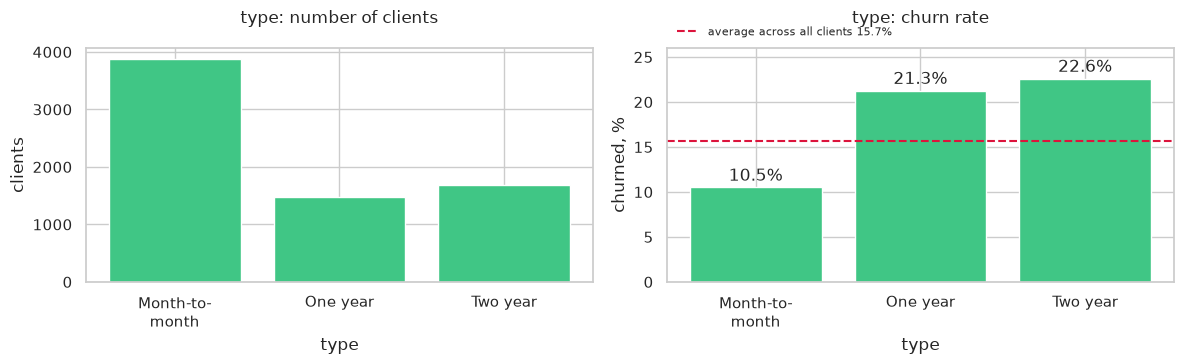

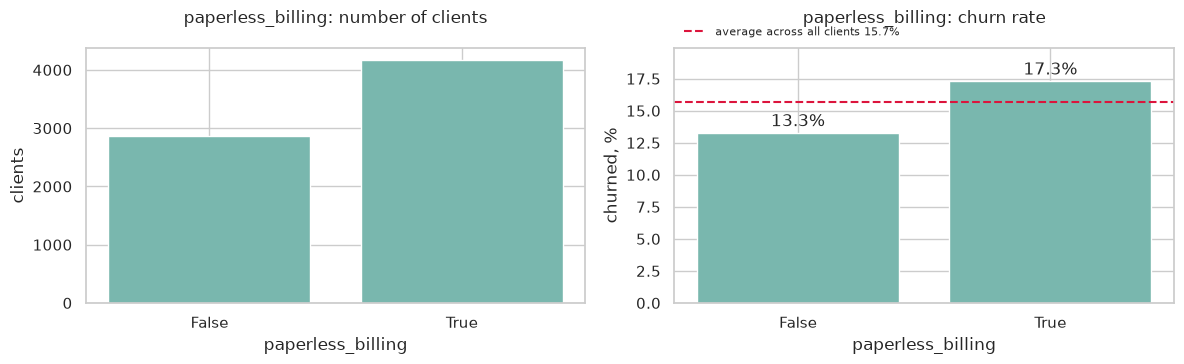

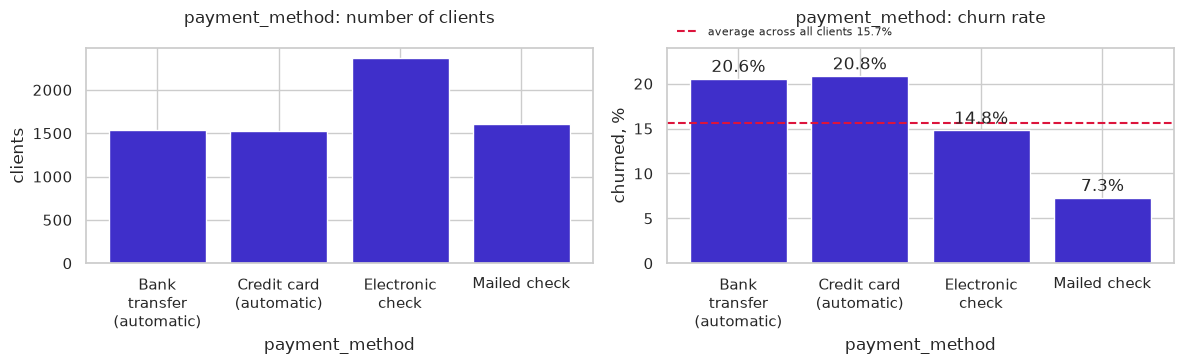

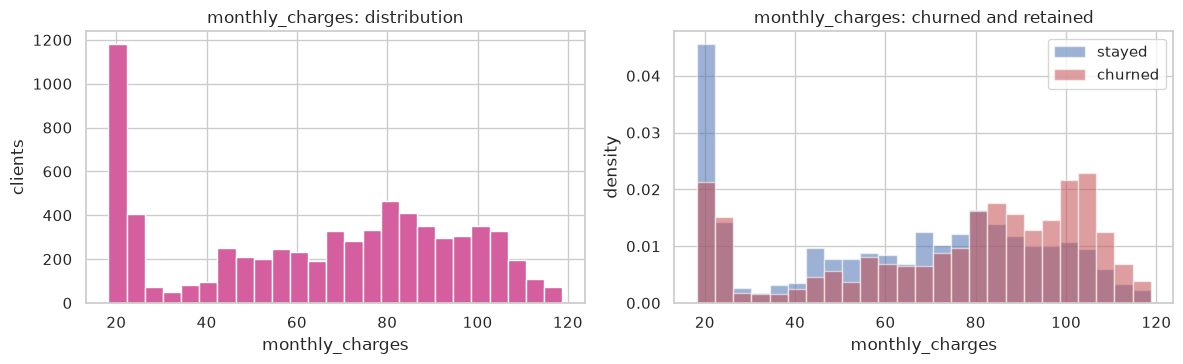

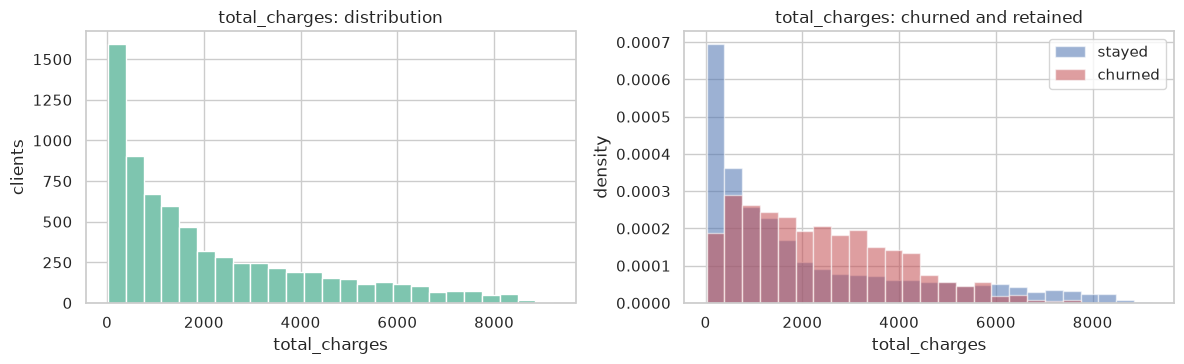

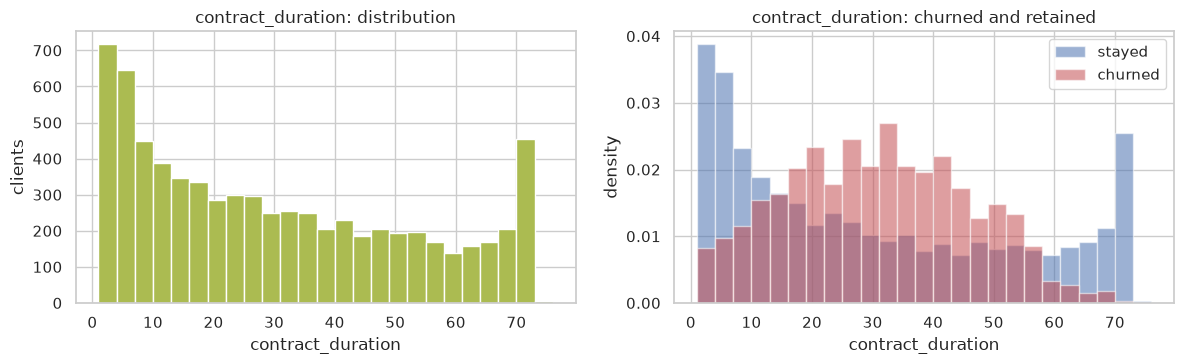

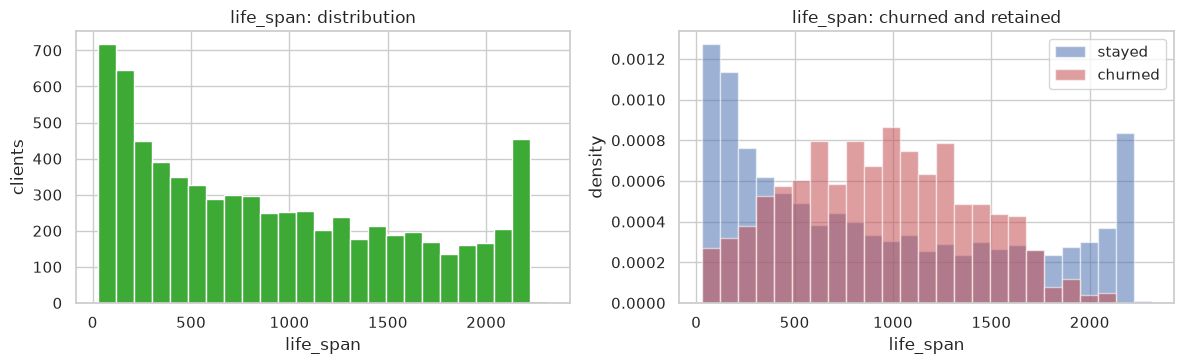

In [58]:
contract_features = ['type', 'paperless_billing', 'payment_method',
                     'monthly_charges', 'total_charges', 'contract_duration', 'life_span']

for feature in contract_features:
    plot_feature(feature)

**Frequency distributions**

- **`type`:** more than half of the base is on a month-to-month contract, 55.1%, two-year contracts account for 24.0%, one-year ones for 20.9%
- **`paperless_billing`:** 59.3% of customers have a paperless billing statement, 40.7% a paper one
- **`payment_method`:** the electronic check leads with 33.6%, the other three methods are almost equal, 21.6–22.8%
- **`monthly_charges`:** the distribution is bimodal, a narrow peak at 18–26 holds 22.6% of customers, a wide plateau at 70–110 another 48.0%, median 70.35
- **`total_charges`:** heavily right-skewed, median 1345 against a mean of 2119, 42.0% of customers sit below 1000, and the tail stretches to 9221
- **`contract_duration`:** a decline from the left edge, 19.4% did not survive to 7 months, with a spike at the right edge, 6.6% at 70–76 months, median 25
- **`life_span`:** the same shape in days, median 761, range 28–2314, and the same 19.4% fit within 200 days

I split each numeric feature into five groups of equal customer count and look at the share of churned customers in each. Next to it is the group's median tenure

In [59]:
quintile_rows = []
for feature in continuous_features:
    grouped = data.groupby(pd.qcut(data[feature], 5), observed=True)
    quintile_rows.append(pd.DataFrame({
        'feature': feature,
        'clients': grouped['churn'].size(),
        'churned, %': grouped['churn'].mean().mul(100).round(1),
        'median tenure, months': grouped['contract_duration'].median(),
    }).rename_axis('interval').reset_index())

pd.concat(quintile_rows).set_index(['feature', 'interval'])

clients  churned, %  \
feature           interval                                 
monthly_charges   (18.249, 25.05]       1416         9.8   
                  (25.05, 58.92]        1397        11.0   
                  (58.92, 79.15]        1415        12.7   
                  (79.15, 94.3]         1404        18.2   
                  (94.3, 118.75]        1400        26.7   
total_charges     (19.049, 335.004]     1407         4.7   
                  (335.004, 917.7]      1408        12.5   
                  (917.7, 1853.68]      1404        17.9   
                  (1853.68, 3848.2]     1406        29.2   
                  (3848.2, 9221.38]     1407        14.1   
contract_duration (0.999, 7.0]          1532         5.0   
                  (7.0, 18.0]           1350        14.3   
                  (18.0, 33.0]          1385        27.0   
                  (33.0, 53.0]          1406        27.2   
                  (53.0, 76.0]          1359         5.5   
life_span         (27.999, 215.0]       1532         5.0   
                  (215.0, 549.0]        1348        14.2   
                  (549.0, 1006.0]       1384        27.0   
                  (1006.0, 1614.0]      1409        27.4   
                  (1614.0, 2314.0]      1359         5.5   

                                     median tenure, months  
feature           interval                                  
monthly_charges   (18.249, 25.05]                     20.0  
                  (25.05, 58.92]                      18.0  
                  (58.92, 79.15]                      19.0  
                  (79.15, 94.3]                       26.0  
                  (94.3, 118.75]                      41.0  
total_charges     (19.049, 335.004]                    3.0  
                  (335.004, 917.7]                    11.0  
                  (917.7, 1853.68]                    23.0  
                  (1853.68, 3848.2]                   34.0  
                  (3848.2, 9221.38]                   61.0  
contract_duration (0.999, 7.0]                         4.0  
                  (7.0, 18.0]                         13.0  
                  (18.0, 33.0]                        26.0  
                  (33.0, 53.0]                        43.0  
                  (53.0, 76.0]                        66.0  
life_span         (27.999, 215.0]                      4.0  
                  (215.0, 549.0]                      13.0  
                  (549.0, 1006.0]                     26.0  
                  (1006.0, 1614.0]                    43.0  
                  (1614.0, 2314.0]                    66.0

The customers who leave least often are those on a month-to-month contract and those paying by mailed check. I check the most obvious explanation, differing tenure. Churn here means "the contract was terminated at some point before February 1, 2020"

In [60]:
long_tenure = data[data['contract_duration'] > 24]

for feature in ['type', 'payment_method']:
    display(pd.DataFrame({
        'clients': data.groupby(feature)['churn'].size(),
        'median tenure, months': data.groupby(feature)['contract_duration'].median(),
        'churned, %': data.groupby(feature)['churn'].mean().mul(100).round(1),
        'churned among tenure > 24 months, %': long_tenure.groupby(feature)['churn'].mean().mul(100).round(1),
    }))

,clients,"median tenure, months","churned, %","churned among tenure > 24 months, %"
type,,,,
Month-to-month,3875,12.0,10.5,18.8
One year,1472,37.0,21.3,19.6
Two year,1685,55.0,22.6,19.9


,clients,"median tenure, months","churned, %","churned among tenure > 24 months, %"
payment_method,,,,
Bank transfer (automatic),1542,39.0,20.6,21.5
Credit card (automatic),1521,37.0,20.8,19.8
Electronic check,2365,17.0,14.8,21.9
Mailed check,1604,14.0,7.3,10.7


The "longer than two years" slice is too broad. I cut tenure into three bands and look at the share of churned customers in each cell, with the number of customers next to it

In [61]:
tenure_bands = pd.cut(data['contract_duration'], [0, 24, 48, 76],
                      labels=['1-24 months', '25-48 months', '49-76 months'])

type_churn_share = pd.crosstab(data['type'], tenure_bands, values=data['churn'],
                               aggfunc='mean', margins=True, margins_name='all').mul(100).round(1)
type_client_count = pd.crosstab(data['type'], tenure_bands, margins=True, margins_name='all')

pd.concat({'churned, %': type_churn_share, 'clients': type_client_count}, axis=1)

churned, %                                     clients  \
contract_duration 1-24 months 25-48 months 49-76 months   all 1-24 months   
type                                                                        
Month-to-month            7.4         21.0         10.7  10.5        2819   
One year                 25.5         27.6          9.2  21.3         411   
Two year                 39.0         45.8          8.6  22.6         236   
all                      11.7         29.0          9.0  15.7        3466   

                                                   
contract_duration 25-48 months 49-76 months   all  
type                                               
Month-to-month             832          224  3875  
One year                   602          459  1472  
Two year                   441         1008  1685  
all                       1875         1691  7032

**What the contract and payments show**

- **Contract type. On the whole, customers with a longer contract leave more often** (10.5% for month-to-month against 21.3% and 22.6%), but this is a tenure effect. Within the same tenure the picture is the reverse: at 1–24 months, 7.4% of month-to-month customers left against 39.0% of two-year ones
- **Payment method. The mailed check stands out sharply,** 7.3% against 14.8–20.8% for the others, and at equal tenure it remains the most loyal group
- **Monthly payment. The larger the bill, the higher the churn,** from 9.8% in the bottom quintile to 26.7% in the top one
- **For the accumulated amount and both duration features the relationship is non-monotonic.** Newcomers leave least often (5.0%), as do long-timers (5.5%), with a maximum of 27% in the middle of the scale. The model needs not a line but a split into intervals, and that is a job for trees
- **The lifetime in days repeats the duration in months** down to the third decimal place

### 7.2 Personal data

Senior citizen status and having a partner

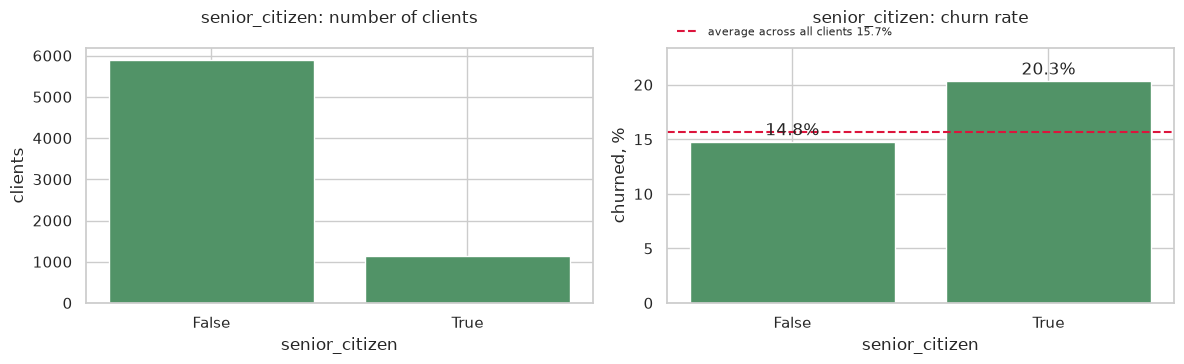

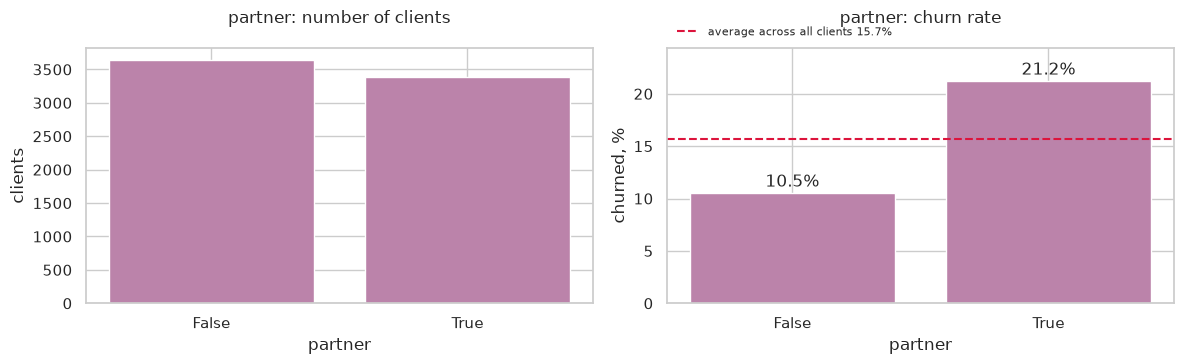

In [62]:
personal_features = ['senior_citizen', 'partner']

for feature in personal_features:
    plot_feature(feature)

**What the personal data shows**

- **Senior citizens leave more often** 20.3% against 14.8%
- **Having a partner is the strongest feature in this group** 21.2% against 10.5%, and the direction is the opposite of the hypothesis about the less mobile family customer

### 7.3 Internet and additional services

The six services sold together with internet

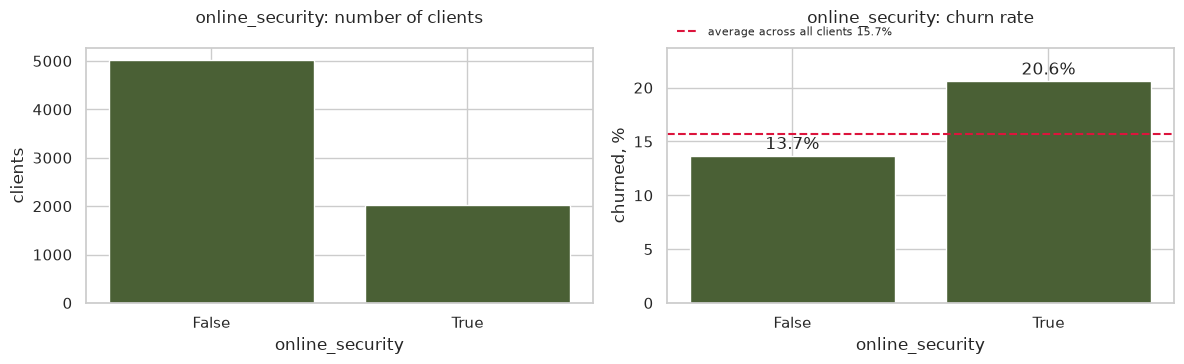

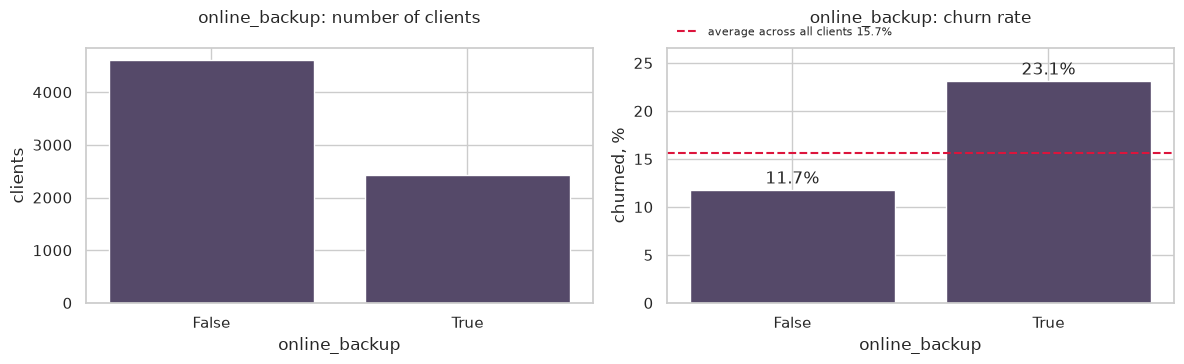

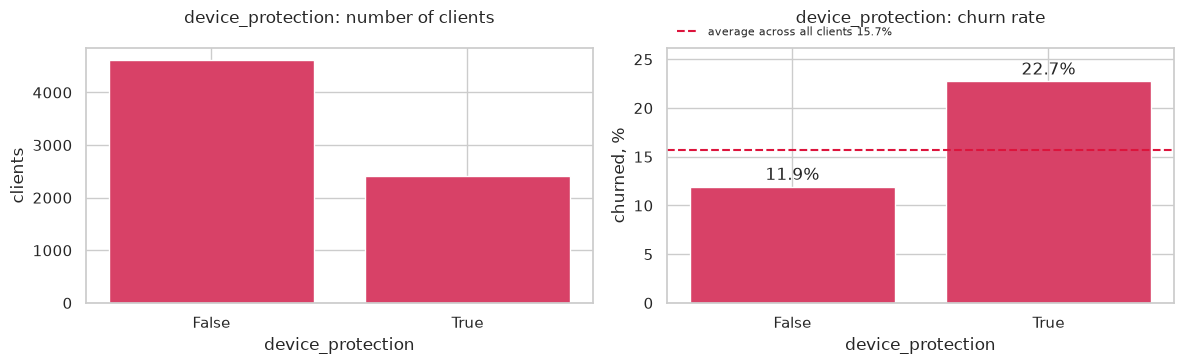

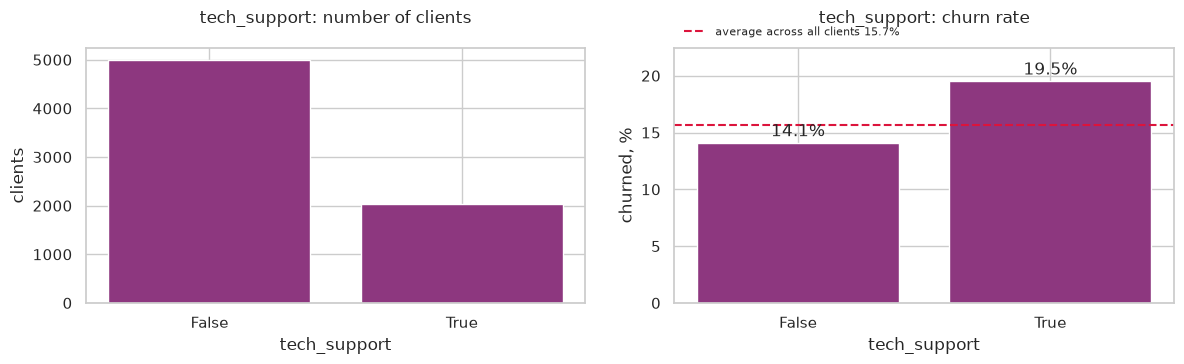

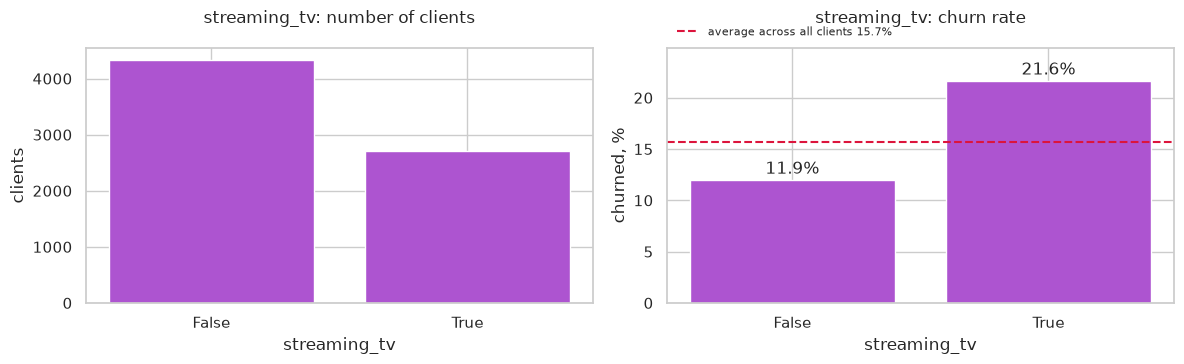

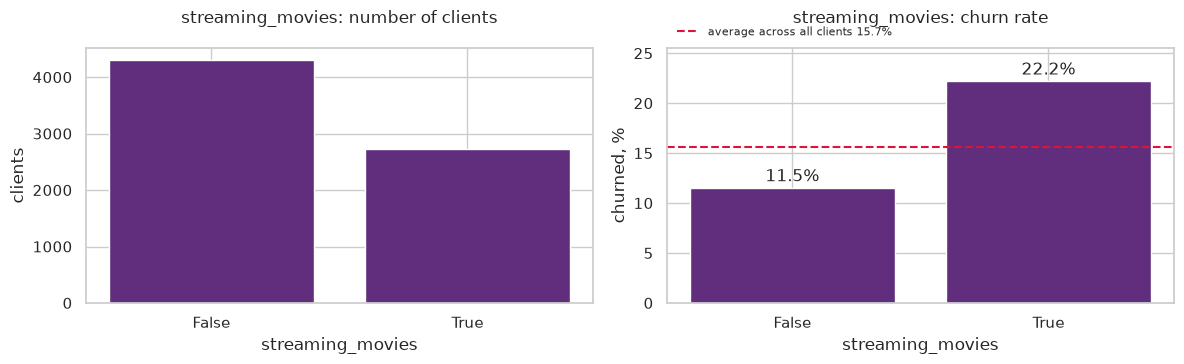

In [63]:
internet_features = ['online_security', 'online_backup', 'device_protection',
                     'tech_support', 'streaming_tv', 'streaming_movies']

for feature in internet_features:
    plot_feature(feature)

**What the internet services show**

- **All six services behave the same way. Where a service is connected, churn is higher,** from 19.5% to 23.1% against 11.5–14.1%. The hypothesis that "the more services, the costlier it is to move" was not confirmed, the sign is the opposite

### 7.4 Telephony and the new features

The only telephony service, the service counter from the beginning of the section and the internet connection flag

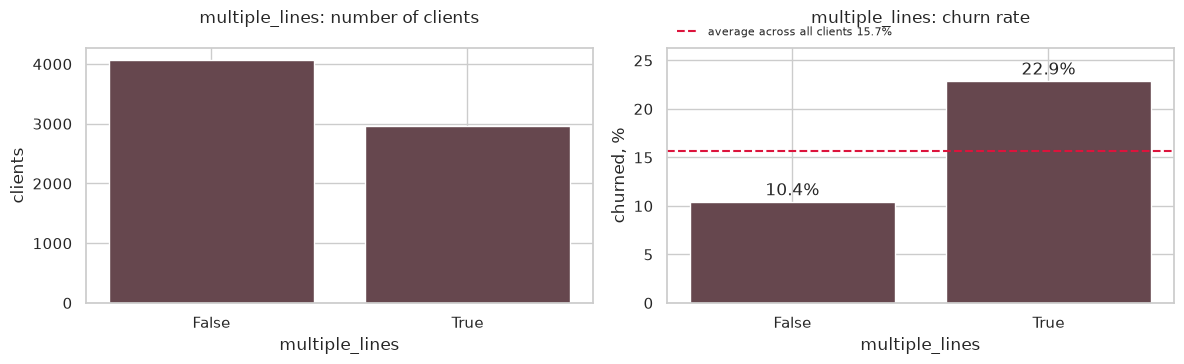

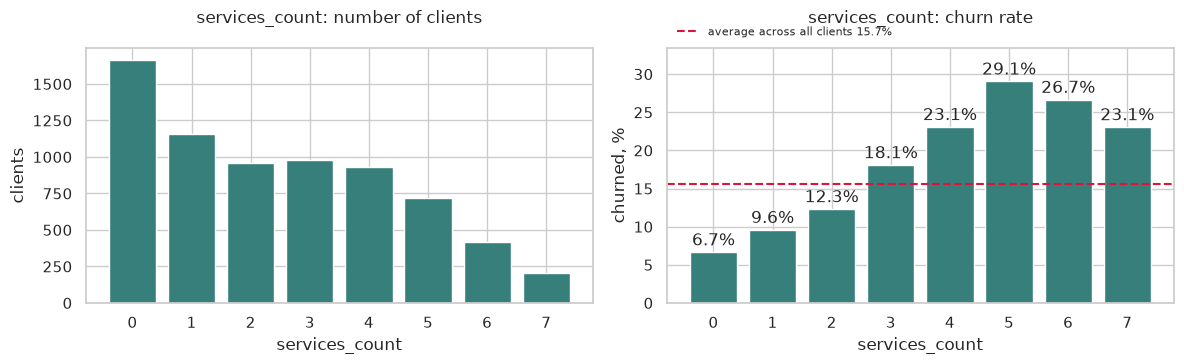

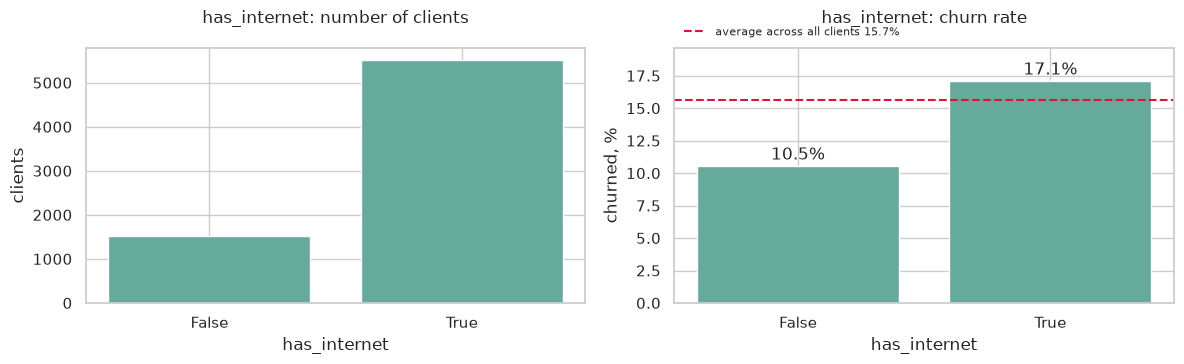

In [64]:
phone_and_new_features = ['multiple_lines', 'services_count', 'has_internet']

for feature in phone_and_new_features:
    plot_feature(feature)

I check the same explanation as in 7.1. Is ordinary tenure hiding behind the number of services

In [65]:
pd.DataFrame({
    'clients': data.groupby('services_count')['churn'].size(),
    'median tenure, months': data.groupby('services_count')['contract_duration'].median(),
    'churned, %': data.groupby('services_count')['churn'].mean().mul(100).round(1),
})

,clients,"median tenure, months","churned, %"
services_count,,,
0,1663,12.0,6.7
1,1156,13.0,9.6
2,957,17.0,12.3
3,978,26.0,18.1
4,931,37.0,23.1
5,719,44.0,29.1
6,420,58.0,26.7
7,208,68.0,23.1


I take the same split, grouping the number of services in pairs. I keep the thinnest cells. A percentage based on fifty customers is a tendency, not an estimate

In [66]:
services_bands = pd.cut(data['services_count'], [-1, 1, 3, 5, 7], labels=['0–1', '2–3', '4–5', '6–7'])

services_churn_share = pd.crosstab(services_bands, tenure_bands, values=data['churn'],
                                   aggfunc='mean', margins=True, margins_name='all').mul(100).round(1)
services_client_count = pd.crosstab(services_bands, tenure_bands, margins=True, margins_name='all')

pd.concat({'churned, %': services_churn_share, 'clients': services_client_count}, axis=1)

churned, %                                     clients  \
contract_duration 1-24 months 25-48 months 49-76 months   all 1-24 months   
services_count                                                              
0–1                       4.9         18.7          7.7   7.9        1899   
2–3                      12.1         23.9          8.7  15.2        1082   
4–5                      32.7         36.1         10.3  25.7         431   
6–7                      74.1         57.2          8.6  25.5          54   
all                      11.7         29.0          9.0  15.7        3466   

                                                   
contract_duration 25-48 months 49-76 months   all  
services_count                                     
0–1                        530          390  2819  
2–3                        590          263  1935  
4–5                        610          609  1650  
6–7                        145          429   628  
all                       1875         1691  7032

**What telephony and the new features show**

- **Multiple lines are a strong separator** 22.9% against 10.4%
- **The service counter gives the widest churn scale** from 6.7% for customers without a single service to 29.1% for those who connected five
- **The number of services is strongly related to tenure but does not reduce to it.** Within the 1–24 month band, 4.9% of customers with zero or one service left against 74.1% of those with six or seven. The contributions of tenure and of the service bundle cannot be separated in EDA, the model will do that. There is no leakage in the counter

I sum the picture up in a table: the minimum and maximum share of churned customers by category and the spread between them. I leave out the four numeric features, they are analyzed by quantiles in 7.1

In [67]:
category_rates = {feature: data.groupby(feature)['churn'].mean().mul(100)
                  for feature in plotted_features if feature not in continuous_features}

churn_spread = pd.DataFrame([
    {'feature': feature, 'categories': len(rates), 'min, %': rates.min(),
     'max, %': rates.max(), 'spread, pp': rates.max() - rates.min()}
    for feature, rates in category_rates.items()
]).set_index('feature').sort_values('spread, pp', ascending=False).round(1)

churn_spread

,categories,"min, %","max, %","spread, pp"
feature,,,,
services_count,8,6.7,29.1,22.4
payment_method,4,7.3,20.8,13.5
multiple_lines,2,10.4,22.9,12.4
type,3,10.5,22.6,12.1
online_backup,2,11.7,23.1,11.3
device_protection,2,11.9,22.7,10.8
partner,2,10.5,21.2,10.7
streaming_movies,2,11.5,22.2,10.7
streaming_tv,2,11.9,21.6,9.7


**Interim conclusion on the choice of the feature set for training**

- Not a single feature splits customers in half by churn. The best by spread is `services_count` at 22.4%, then `payment_method` 13.5% and `multiple_lines` 12.4%. Quality will come from adding up weak signals
- Many associations are mediated by tenure, but they are not exhausted by it, the model will apportion the contributions
- For `contract_duration`, `life_span` and `total_charges` the relationship is non-monotonic, which is an argument for trees

**What I take into training.** Seventeen features, written out as an explicit list in section 8. I do not take `customer_id`, both dates (forbidden by the project specification), `contract_duration` (exactly one derivative of `begin_date` goes into `X`, and the daily scale is more precise than the monthly one) and the three candidates from 6.4 that are weaker than their sources. `gender`, `dependents` and `internet_service` were filtered out earlier, in 6.3

<div class="alert alert-success">
<h2> Mentor's comment<a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> Excellent, the plots are easy to read, the conclusions are logical, and one can build a profile of a churning customer. This kind of information is useful for the business

## 8. Preparing the samples

I assemble the matrix from the set defined in section 7, split the data 75 to 25 with `stratify` and describe the transformations. I set the test set aside and do not touch it until the final check

I split the features into three groups: two text columns to encode, four numeric ones to bring to a common scale, and eleven flags that are already `bool`. A flag needs no encoding, one-hot would expand each of them into two mirror columns, so exactly two categorical features remain: `type` and `payment_method`

In [68]:
model_features = ['type', 'paperless_billing', 'payment_method', 'monthly_charges',
                  'total_charges', 'life_span', 'senior_citizen', 'partner',
                  'online_security', 'online_backup', 'device_protection', 'tech_support',
                  'streaming_tv', 'streaming_movies', 'multiple_lines', 'services_count',
                  'has_internet']

categorical_features = ['type', 'payment_method']
numeric_features = ['monthly_charges', 'total_charges', 'life_span', 'services_count']
binary_features = ['paperless_billing', 'senior_citizen', 'partner', 'online_security',
                   'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
                   'streaming_movies', 'multiple_lines', 'has_internet']

len(model_features)

17

I verify the list against the table before building anything from it: all seventeen names are present in `data`, none of the forbidden ones are there, there is exactly one derivative of the dates and it is named explicitly, and the three groups cover the list without overlapping

In [69]:
forbidden_features = ['customer_id', 'begin_date', 'end_date', 'contract_duration']
date_derived_suffixes = ('_age', '_days', '_months', '_year', '_month', '_since', '_until',
                        '_duration', '_span')
sanctioned_date_features = ['life_span']
date_derived = [column for column in data.columns
                if column.endswith(date_derived_suffixes)]
unsanctioned_date_derived = [column for column in date_derived
                             if column not in sanctioned_date_features]
grouped_features = categorical_features + numeric_features + binary_features

pd.Series({
    'features in the list': len(model_features),
    'not in the master table': sorted(set(model_features) - set(data.columns)),
    'forbidden ones in the list': sorted(set(forbidden_features) & set(model_features)),
    'date-derived features in the list': sorted(set(date_derived) & set(model_features)),
    'of which inconsistent': sorted(set(unsanctioned_date_derived) & set(model_features)),
    'groups cover the list': set(grouped_features) == set(model_features),
    'features in the two groups': len(grouped_features) - len(set(grouped_features)),
}, name='value').to_frame()

,value
features in the list,17
not in the master table,[]
forbidden ones in the list,[]
date-derived features in the list,[life_span]
of which inconsistent,[]
groups cover the list,True
features in the two groups,0


I assemble the feature matrix and the target vector and split them into two sets. `stratify` keeps the share of churned customers the same, and `random_state` makes the split reproducible

In [70]:
X = data[model_features]
y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

X_train.shape, X_test.shape

((5274, 17), (1758, 17))

The shares of churned customers in both sets should match the overall 15.7%

In [71]:
pd.DataFrame({
    'clients': [len(X_train), len(X_test), len(X)],
    'churned': [y_train.sum(), y_test.sum(), y.sum()],
    'churned, %': [100 * y_train.mean(), 100 * y_test.mean(), 100 * y.mean()],
}, index=['train', 'test', 'whole sample']).round(2)

,clients,churned,"churned, %"
train,5274,826,15.66
test,1758,275,15.64
whole sample,7032,1101,15.66


I encode the two categorical columns with one-hot, bring the four numbers to a common scale for the sake of the neural network, and pass the eleven flags through as they are. `drop=None` keeps all the categories: there are no linear models in the project, and this way is more convenient for trees. `handle_unknown='ignore'` insures against an unseen category

In [72]:
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None),
     categorical_features),
    ('numeric', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

<div class="alert alert-warning">
    <h2> Mentor's comment <a class="tocSkip"> </h2>
    
<b>Some remarks and recommendations💡:</b> For the future - it does not show here, but when training tree-based models (plain trees, forest, lgbm, catboost) it is undesirable to use OHE for high-cardinality categorical features (features with a large number of unique values). To reach good accuracy in that case you have to grow a very deep tree, which is fairly resource-intensive. For this reason such trees often remain underfitted and unbalanced. Instead of OHE it is better to use ordinal encoding (<a href = 'https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder'>OrdinalEncoder</a>) for such features, thanks to which a single step of tree training can split all the categories into two subsets at once, which helps to avoid taking too many steps to go deeper.
    
    
On top of that, lgbm and catboost even have special parameters through which you can specify the list of features that need encoding (although by default the models can determine themselves which features are categorical, this does not always work reliably, so to avoid misunderstandings with the model it is better to spell out the features that need encoding manually): categorical_feature and cat_features respectively.

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Student's comment</b></font>
The cardinality here is 3 and 4 categories, OHE adds 5 columns out of 22, the depth of the trees does not suffer from that, so I did not introduce OrdinalEncoder. Categories without encoding take part in the work as well: in 9.5 CatBoost takes them through cat_features.
</div>

I look at what the table turns into after encoding. In the models the same `preprocessor` lives inside a `Pipeline`, is refitted on every fold and never sees the test set

In [73]:
train_encoded_preview = preprocessor.fit_transform(X_train)
one_hot_encoder = preprocessor.named_transformers_['categorical']

display(pd.Series({feature: len(categories) for feature, categories
                   in zip(categorical_features, one_hot_encoder.categories_)},
                  name='categories').to_frame().T)

display(pd.Series({
    'rows in train': train_encoded_preview.shape[0],
    'columns after the transformation': train_encoded_preview.shape[1],
    'of which one-hot': sum(len(categories) for categories in one_hot_encoder.categories_),
    'scaled numbers': len(numeric_features),
    'flags unchanged': len(binary_features),
}, name='value').to_frame())

train_encoded_preview.shape

,type,payment_method
categories,3,4


,value
rows in train,5274
columns after the transformation,22
of which one-hot,7
scaled numbers,4
flags unchanged,11


(5274, 22)

**Interim conclusion for this section**

- `X` has seventeen columns and the verification came out clean: there are no forbidden names, and there is one derivative of the dates, named explicitly
- A 75 to 25 split with stratification: 5274 customers in train and 1758 in test, with churn shares of 15.66% and 15.64%
- `ColumnTransformer` gives the model 22 features at the input instead of 17: `type` three categories plus `payment_method` four, four numbers and eleven flags
- The test set is isolated until the final check

## 9. Training the models

I train a decision tree, gradient boosting and a neural network, each inside a pipeline with the preprocessor from section 8: the transformations are refitted on the training part of every fold and peek neither at the held-out fold nor at the test set. I tune the hyperparameters with `OptunaSearchCV` by ROC-AUC on five-fold cross-validation, and the folds are the same for all models. Of the boosting implementations I take `HistGradientBoostingClassifier` for its speed and for the `l2_regularization` parameter, which regularizes the values in the leaves. That does not cure multicollinearity, so I will still read feature importance in groups

I create the split once and pass it to all the models. The cache is needed because each search takes minutes; before submitting I delete the folder and run the notebook from scratch. The cache does not notice a change of grid, data or preprocessor

In [74]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cache_dir = 'graduation_project/cache' if os.path.isdir('graduation_project') else 'cache'
os.makedirs(cache_dir, exist_ok=True)

cache_dir

'cache'

I move the "check the cache, otherwise run the search and measure the time" logic into a function, and next to it a second one that folds the result into a small table. I set `n_jobs=-1`, all the cores of the machine

In [75]:
def run_search(name, estimator, param_distributions, n_trials, **fit_params):
    cache_path = os.path.join(cache_dir, f'{name}.joblib')
    if os.path.exists(cache_path):
        search, seconds = joblib.load(cache_path)
        return search, seconds, True

    search = OptunaSearchCV(estimator, param_distributions, cv=cv, scoring='roc_auc',
                            n_trials=n_trials, n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
    started = time.perf_counter()
    search.fit(X_train, y_train, **fit_params)
    seconds = time.perf_counter() - started

    joblib.dump((search, seconds), cache_path)
    return search, seconds, False

In [76]:
def search_summary(search, seconds, from_cache):
    return pd.Series({
        'ROC-AUC on cross-validation': round(search.best_score_, 4),
        'tuning trials': len(search.trials_),
        'search time, min': round(seconds / 60, 1),
        'from cache': 'yes' if from_cache else 'no',
        **{name.replace('model__', ''): value for name, value in search.best_params_.items()},
    }, name='value').to_frame()

`DummyClassifier` with the `prior` strategy gives everyone the same churn probability, so its ROC-AUC is exactly 0.5. Everything the models show above that line comes from the features

In [77]:
baseline_pipeline = Pipeline([('preprocessing', preprocessor),
                              ('model', DummyClassifier(strategy='prior'))])

baseline_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

pd.Series({
    'ROC-AUC by fold': ', '.join(f'{score:.3f}' for score in baseline_scores),
    'mean ROC-AUC': round(baseline_scores.mean(), 4),
}, name='value').to_frame()

,value
ROC-AUC by fold,"0.500, 0.500, 0.500, 0.500, 0.500"
mean ROC-AUC,0.5


### 9.1 Decision tree

A single tree sets the lower bound of quality for tree-based models. I tune `max_depth` from 2 to 12, `min_samples_leaf` from 3 to 100 on a logarithmic scale and `class_weight` in both variants

In [78]:
tree_pipeline = Pipeline([('preprocessing', preprocessor),
                          ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))])

tree_space = {
    'model__max_depth': IntDistribution(2, 12),
    'model__min_samples_leaf': IntDistribution(3, 100, log=True),
    'model__class_weight': CategoricalDistribution([None, 'balanced']),
}

tree_search, tree_seconds, tree_cached = run_search('decision_tree', tree_pipeline, tree_space, 40)

search_summary(tree_search, tree_seconds, tree_cached)

,value
ROC-AUC on cross-validation,0.797
tuning trials,40
"search time, min",0.1
from cache,no
max_depth,12
min_samples_leaf,88
class_weight,None


### 9.2 Gradient boosting

`HistGradientBoostingClassifier` builds trees one after another, each correcting the errors of the previous ones. I tune `learning_rate` from 0.01 to 0.2 and `max_iter` from 50 to 300 together, `max_leaf_nodes` from 15 to 63 and `l2_regularization` from 0.001 to 10

In [79]:
hist_pipeline = Pipeline([('preprocessing', preprocessor),
                          ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE))])

hist_space = {
    'model__learning_rate': FloatDistribution(0.01, 0.2, log=True),
    'model__max_iter': IntDistribution(50, 300),
    'model__max_leaf_nodes': IntDistribution(15, 63),
    'model__l2_regularization': FloatDistribution(1e-3, 10, log=True),
}

hist_search, hist_seconds, hist_cached = run_search('hist_boosting', hist_pipeline, hist_space, 40)

search_summary(hist_search, hist_seconds, hist_cached)

,value
ROC-AUC on cross-validation,0.8886
tuning trials,40
"search time, min",3.6
from cache,no
learning_rate,0.197126
max_iter,297
max_leaf_nodes,48
l2_regularization,1.726741


### 9.3 Neural network

`MLPClassifier`, which cares about feature scale. I fix `adam`, `relu`, a batch of 64, a ceiling of 500 epochs and early stopping. I search over five architectures from 16 neurons to two layers of 64 and 32, `alpha` from 0.00001 to 0.1 and `learning_rate_init` from 0.0001 to 0.005, with 30 trials

In [80]:
mlp_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', MLPClassifier(solver='adam', activation='relu', batch_size=64, max_iter=500,
                            early_stopping=True, validation_fraction=0.15, n_iter_no_change=15,
                            random_state=RANDOM_STATE)),
])

mlp_space = {
    'model__hidden_layer_sizes': CategoricalDistribution([(16,), (32,), (64,), (32, 16), (64, 32)]),
    'model__alpha': FloatDistribution(1e-5, 1e-1, log=True),
    'model__learning_rate_init': FloatDistribution(1e-4, 5e-3, log=True),
}

mlp_search, mlp_seconds, mlp_cached = run_search('mlp', mlp_pipeline, mlp_space, 30)

search_summary(mlp_search, mlp_seconds, mlp_cached)

,value
ROC-AUC on cross-validation,0.8252
tuning trials,30
"search time, min",2.0
from cache,no
hidden_layer_sizes,"(64,)"
alpha,0.000028
learning_rate_init,0.004919


### 9.4 Extended search

The compact search gave 0.8934 with `HistGB`. I widen the ranges, add parameters and increase the number of trials, with the same cross-validation — checking whether wide grids squeeze out more

For the tree I add `criterion`, `max_features` and `ccp_alpha`, raise the depth ceiling to 18 and the leaf size to 150. 80 trials

In [81]:
wide_tree_space = {
    'model__criterion': CategoricalDistribution(['gini', 'log_loss']),
    'model__max_depth': IntDistribution(2, 18),
    'model__min_samples_leaf': IntDistribution(2, 150, log=True),
    'model__max_features': FloatDistribution(0.5, 1.0),
    'model__ccp_alpha': FloatDistribution(1e-7, 2e-2, log=True),
    'model__class_weight': CategoricalDistribution([None, 'balanced']),
}

wide_tree_search, wide_tree_seconds, wide_tree_cached = run_search(
    'decision_tree_wide', tree_pipeline, wide_tree_space, 80)

search_summary(wide_tree_search, wide_tree_seconds, wide_tree_cached)

,value
ROC-AUC on cross-validation,0.7966
tuning trials,80
"search time, min",0.2
from cache,no
criterion,gini
max_depth,7
min_samples_leaf,84
max_features,0.873055
ccp_alpha,0.000001
class_weight,balanced


The classic `GradientBoostingClassifier` resists overfitting independently of `l2_regularization`: `subsample` trains each tree on a random part of the customers, `max_features` on a random part of the features. From 150 to 700 trees at a depth of 1 to 4, early stopping, 90 trials

In [82]:
gb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier(n_iter_no_change=15, validation_fraction=0.12,
                                         random_state=RANDOM_STATE)),
])

gb_space = {
    'model__n_estimators': IntDistribution(150, 700, step=25),
    'model__learning_rate': FloatDistribution(0.008, 0.2, log=True),
    'model__max_depth': IntDistribution(1, 4),
    'model__min_samples_leaf': IntDistribution(5, 80, log=True),
    'model__subsample': FloatDistribution(0.6, 1.0),
    'model__max_features': FloatDistribution(0.6, 1.0),
}

gb_search, gb_seconds, gb_cached = run_search('gradient_boosting', gb_pipeline, gb_space, 90)

search_summary(gb_search, gb_seconds, gb_cached)

,value
ROC-AUC on cross-validation,0.8603
tuning trials,90
"search time, min",2.0
from cache,no
n_estimators,350
learning_rate,0.108224
max_depth,3
min_samples_leaf,5
subsample,0.870633
max_features,0.982365


For the neural network I add `tanh` and `batch_size` from 32 to 256, widen `alpha` and the initial step by an order of magnitude, and add 128 and the pair 128 with 64 to the architectures. 90 trials

In [83]:
wide_mlp_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', MLPClassifier(solver='adam', max_iter=500, early_stopping=True,
                            validation_fraction=0.15, n_iter_no_change=15,
                            random_state=RANDOM_STATE)),
])

wide_mlp_space = {
    'model__hidden_layer_sizes': CategoricalDistribution(
        [(16,), (32,), (64,), (128,), (32, 16), (64, 32), (128, 64)]),
    'model__activation': CategoricalDistribution(['relu', 'tanh']),
    'model__batch_size': CategoricalDistribution([32, 64, 128, 256]),
    'model__alpha': FloatDistribution(1e-6, 1e-1, log=True),
    'model__learning_rate_init': FloatDistribution(5e-5, 1e-2, log=True),
}

wide_mlp_search, wide_mlp_seconds, wide_mlp_cached = run_search(
    'mlp_wide', wide_mlp_pipeline, wide_mlp_space, 90)

search_summary(wide_mlp_search, wide_mlp_seconds, wide_mlp_cached)

,value
ROC-AUC on cross-validation,0.8275
tuning trials,90
"search time, min",7.1
from cache,no
hidden_layer_sizes,"(64,)"
activation,relu
batch_size,64
alpha,0.00002
learning_rate_init,0.002971


### 9.5 CatBoost with native categorical features

Six searches gave from 0.7960 to 0.8934. I test the explanation that the point is not the models but the one-hot encoding of the categories: `CatBoost` builds splits on categories directly and needs no preprocessor. I tune `iterations` from 300 to 1500, `depth` from 3 to 6, `learning_rate` from 0.01 to 0.2 and `l2_leaf_reg` from 1 to 30, with 35 trials. I also put `auto_class_weights` in here: the classes are 15.7 against 84.3, so let the search itself decide whether the rare class needs a weight

In [84]:
catboost_model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0,
                                    allow_writing_files=False)

catboost_space = {
    'iterations': IntDistribution(300, 1500),
    'depth': IntDistribution(3, 6),
    'learning_rate': FloatDistribution(0.01, 0.2, log=True),
    'l2_leaf_reg': FloatDistribution(1, 30, log=True),
    'auto_class_weights': CategoricalDistribution(['None', 'Balanced']),
}

catboost_search, catboost_seconds, catboost_cached = run_search(
    'catboost', catboost_model, catboost_space, 35, cat_features=categorical_features)

search_summary(catboost_search, catboost_seconds, catboost_cached)

,value
ROC-AUC on cross-validation,0.9225
tuning trials,35
"search time, min",2.0
from cache,no
iterations,1461
depth,3
learning_rate,0.184416
l2_leaf_reg,3.99325
auto_class_weights,None


**What CatBoost gave**

0.9219 against 0.8934 for the best search on one-hot, a difference of +0.0285, which is consistent with the hypothesis about categorical encoding, although different model families are being compared. The search did not take the rare-class weight, `auto_class_weights` stayed 'None': balancing the classes did not improve cross-validation. The specification threshold of 0.85 is already exceeded on cross-validation, with a margin of 0.0719

### 9.6 Ensemble

The families diverged widely, from 0.7960 to 0.9219, so averaging them to cancel out noise makes no sense. I check something else: each family collects the smeared-out signal in its own way and errs on different customers, so I take the ensemble as insurance against the single leader having adapted to the cross-validation

I add up not probabilities but ranks, because the probabilities are calibrated differently while ROC-AUC only looks at the ordering. I freeze the scale on the training data, otherwise a customer's score would depend on who else arrived in the same file

`fit` trains each base model twice: by folds, to get predictions on unseen data for the frozen scale, and on the whole training part. `predict_proba` converts a prediction into a rank via `np.searchsorted` and averages the three ranks

In [85]:
class RankAverageEnsemble(ClassifierMixin, BaseEstimator):
    def __init__(self, models, cv):
        self.models = models
        self.cv = cv

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.fitted_models_ = []
        self.score_grids_ = []
        for model, fit_kwargs in self.models:
            out_of_fold = cross_val_predict(model, X, y, cv=self.cv, method='predict_proba',
                                            params=fit_kwargs)[:, 1]
            self.score_grids_.append(np.sort(out_of_fold))
            self.fitted_models_.append(clone(model).fit(X, y, **fit_kwargs))
        return self

    def predict_proba(self, X):
        ranks = [np.searchsorted(grid, model.predict_proba(X)[:, 1]) / len(grid)
                 for grid, model in zip(self.score_grids_, self.fitted_models_)]
        churn_score = np.mean(ranks, axis=0)
        return np.column_stack([1 - churn_score, churn_score])

Into the ensemble I take the best representatives of the three families: CatBoost on native categorical features, gradient boosting on one-hot and the neural network from 9.4. `clone` returns a model with the same parameters but untrained

In [86]:
ensemble_models = [
    (clone(catboost_search.best_estimator_), {'cat_features': categorical_features}),
    (clone(gb_search.best_estimator_), {}),
    (clone(wide_mlp_search.best_estimator_), {}),
]

rank_ensemble = RankAverageEnsemble(ensemble_models, cv)

pd.Series({'CatBoost, native categories': catboost_search.best_score_,
           'GradientBoosting, wide search': gb_search.best_score_,
           'neural net, wide search': wide_mlp_search.best_score_},
          name='CV ROC-AUC').round(4).to_frame()

,CV ROC-AUC
"CatBoost, native categories",0.9225
"GradientBoosting, wide search",0.8603
"neural net, wide search",0.8275


I evaluate the ensemble with the same cross-validation. Inside each fold the wrapper builds the scale anew, so it sees the held-out fold for the first time

In [87]:
ensemble_cache_path = os.path.join(cache_dir, 'rank_average_ensemble.joblib')

if os.path.exists(ensemble_cache_path):
    ensemble_scores, ensemble_seconds = joblib.load(ensemble_cache_path)
else:
    started = time.perf_counter()
    ensemble_scores = cross_val_score(rank_ensemble, X_train, y_train, cv=cv,
                                      scoring='roc_auc', n_jobs=-1)
    ensemble_seconds = time.perf_counter() - started
    joblib.dump((ensemble_scores, ensemble_seconds), ensemble_cache_path)

pd.Series({
    'ROC-AUC by fold': ', '.join(f'{score:.3f}' for score in ensemble_scores),
    'mean ROC-AUC': round(ensemble_scores.mean(), 4),
    'evaluation time, min': round(ensemble_seconds / 60, 1),
}, name='value').to_frame()

,value
ROC-AUC by fold,"0.879, 0.886, 0.896, 0.882, 0.888"
mean ROC-AUC,0.8862
"evaluation time, min",0.5


I check the key property of the construction. A customer's score must not depend on who arrived together with them

In [88]:
rank_ensemble.fit(X_train, y_train)

whole_batch = rank_ensemble.predict_proba(X_train)[:, 1]
small_batch = rank_ensemble.predict_proba(X_train.head(25))[:, 1]
single_client = rank_ensemble.predict_proba(X_train.head(1))[:, 1]

pd.Series({
    'clients in the check': len(X_train),
    'a batch of 25 gave the same scores': bool(np.allclose(whole_batch[:25], small_batch)),
    'one client gave the same score': bool(np.allclose(whole_batch[:1], single_client)),
}, name='value').to_frame()

,value
clients in the check,5274
a batch of 25 gave the same scores,True
one client gave the same score,True


**What the ensemble gave**

0.8819, which is 0.0400 below the best single model, with a spread of 0.013 between folds. The insurance was not needed. `CatBoost` pulled far ahead, and averaging ranks with weaker families drags it down. This is a normal outcome of the check, not a breakdown. The property for which the scale was frozen was confirmed: a customer's score is the same for batches ranging from a single customer to the whole sample

I summarize the seven searches, the baseline and the ensemble in a table, with tuning time and best parameters

In [89]:
searches = {'tree, compact search': (tree_search, tree_seconds),
            'HistGB, compact search': (hist_search, hist_seconds),
            'neural net, compact search': (mlp_search, mlp_seconds),
            'tree, wide search': (wide_tree_search, wide_tree_seconds),
            'GradientBoosting, wide search': (gb_search, gb_seconds),
            'neural net, wide search': (wide_mlp_search, wide_mlp_seconds),
            'CatBoost, native categories': (catboost_search, catboost_seconds)}

leaderboard_rows = [{'model': 'DummyClassifier baseline', 'CV ROC-AUC': baseline_scores.mean(),
                     'search time, min': 0.0, 'best parameters': 'nothing to tune'}]

for name, (search, seconds) in searches.items():
    best_params = {key.replace('model__', ''): f'{value:.3g}' if isinstance(value, float) else value
                   for key, value in search.best_params_.items()}
    leaderboard_rows.append({'model': name, 'CV ROC-AUC': search.best_score_,
                             'search time, min': round(seconds / 60, 1),
                             'best parameters': ', '.join(f'{key}={value}'
                                                           for key, value in best_params.items())})

leaderboard_rows.append({'model': 'rank ensemble of three families',
                         'CV ROC-AUC': ensemble_scores.mean(),
                         'search time, min': round(ensemble_seconds / 60, 1),
                         'best parameters': 'nothing to tune, equal weights'})

leaderboard = pd.DataFrame(leaderboard_rows).set_index('model').sort_values(
    'CV ROC-AUC', ascending=False).round(4)

leaderboard

,CV ROC-AUC,"search time, min",best parameters
model,,,
"CatBoost, native categories",0.9225,2.0,"iterations=1461, depth=3, learning_rate=0.184,..."
"HistGB, compact search",0.8886,3.6,"learning_rate=0.197, max_iter=297, max_leaf_no..."
rank ensemble of three families,0.8862,0.5,"nothing to tune, equal weights"
"GradientBoosting, wide search",0.8603,2.0,"n_estimators=350, learning_rate=0.108, max_dep..."
"neural net, wide search",0.8275,7.1,"hidden_layer_sizes=(64,), activation=relu, bat..."
"neural net, compact search",0.8252,2.0,"hidden_layer_sizes=(64,), alpha=2.75e-05, lear..."
"tree, compact search",0.7970,0.1,"max_depth=12, min_samples_leaf=88, class_weigh..."
"tree, wide search",0.7966,0.2,"criterion=gini, max_depth=7, min_samples_leaf=..."
DummyClassifier baseline,0.5000,0.0,nothing to tune


`n_estimators` for gradient boosting could have turned out to be a ceiling rather than a fact. Early stopping is enabled in the model. I look at the actual number of trees

In [90]:
best_gradient_boosting = gb_search.best_estimator_.named_steps['model']

pd.Series({
    'n_estimators ceiling': best_gradient_boosting.n_estimators,
    'trees actually fitted': int(best_gradient_boosting.n_estimators_),
    'early stopping triggered': bool(best_gradient_boosting.n_estimators_
                                       < best_gradient_boosting.n_estimators),
}, name='value').to_frame()

,value
n_estimators ceiling,350
trees actually fitted,245
early stopping triggered,True


I record the best single model. Which configuration to take to the test I decide at the end of the section, before opening the test set

In [91]:
best_model_name = max(searches, key=lambda name: searches[name][0].best_score_)
best_search = searches[best_model_name][0]
best_cv_score = max(best_search.best_score_, ensemble_scores.mean())

pd.Series({
    'best single model': best_model_name,
    'its ROC-AUC on cross-validation': round(best_search.best_score_, 4),
    'rank ensemble, ROC-AUC': round(ensemble_scores.mean(), 4),
    'best result above the baseline by': round(best_cv_score - baseline_scores.mean(), 4),
    '0.85 threshold on cross-validation': 'passed' if best_cv_score >= 0.85 else 'failed',
}, name='value').to_frame()

,value
best single model,"CatBoost, native categories"
its ROC-AUC on cross-validation,0.9225
"rank ensemble, ROC-AUC",0.8862
best result above the baseline by,0.4225
0.85 threshold on cross-validation,passed


<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> good, a detailed and correct modeling section, plus a point for exploring different feature processing for boosting, and a clear presentation of the results

### 9.7 What the best model relies on

I analyze what the best model relies on using the training set, the test rows are not needed for this

I compute the contributions with SHAP. It decomposes each prediction into a sum of contributions and for trees computes them exactly. For correlated features the contribution is assigned arbitrarily, so I read groups rather than individual lines of the ranking

I take the model already refitted on the whole training set and compute the contributions for the same 5274 customers

In [92]:
best_catboost = catboost_search.best_estimator_
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
shap_values = shap.TreeExplainer(best_catboost).shap_values(train_pool)

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train.columns,
                            name='mean |contribution|, log-odds').sort_values(ascending=False)

display(shap_importance.round(4).to_frame())

shap_values.shape

,"mean |contribution|, log-odds"
life_span,1.7358
total_charges,1.2018
type,0.6391
partner,0.4106
monthly_charges,0.3975
payment_method,0.2568
multiple_lines,0.2276
services_count,0.1839
tech_support,0.1421
paperless_billing,0.1406


(5274, 17)

The length of a bar is the mean absolute contribution to the odds of churn across customers, and the labels are the shares in the total of the contributions

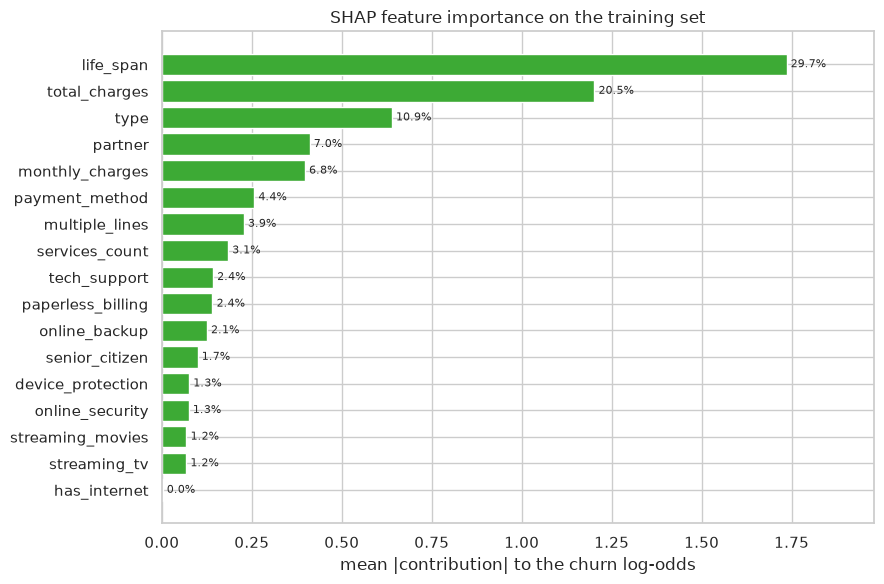

In [93]:
shap_share = 100 * shap_importance / shap_importance.sum()

fig, ax = plt.subplots(figsize=(9, 6))
importance_bars = ax.barh(shap_importance.index[::-1], shap_importance.to_numpy()[::-1],
                          color=feature_colors['life_span'])
ax.bar_label(importance_bars, labels=[f'{share:.1f}%' for share in shap_share[::-1]],
             padding=3, fontsize=8)
ax.margins(x=0.14)
ax.set(xlabel='mean |contribution| to the churn log-odds',
       title='SHAP feature importance on the training set')
plt.tight_layout()
plt.show()

I add up the contributions across four blocks: money and tenure, contract terms and payment, the service bundle, and personal data

In [94]:
feature_groups = {
    'money and tenure': ['monthly_charges', 'total_charges', 'life_span'],
    'contract and payment': ['type', 'paperless_billing', 'payment_method'],
    'services': ['online_security', 'online_backup', 'device_protection', 'tech_support',
               'streaming_tv', 'streaming_movies', 'multiple_lines', 'services_count',
               'has_internet'],
    'personal data': ['senior_citizen', 'partner'],
}

group_importance = pd.DataFrame([
    {'group': group, 'features': len(features),
     'sum of |contribution|': shap_importance[features].sum(),
     'contribution share, %': 100 * shap_importance[features].sum() / shap_importance.sum()}
    for group, features in feature_groups.items()
]).set_index('group').sort_values('contribution share, %', ascending=False).round(3)

display(group_importance)

sum(len(features) for features in feature_groups.values())

,features,sum of |contribution|,"contribution share, %"
group,,,
money and tenure,3,3.335,57.021
contract and payment,3,1.036,17.721
services,9,0.967,16.539
personal data,2,0.510,8.719


17

**What SHAP showed**

- Not a single feature carries the prediction on its own. The leader is `life_span` with 27.8%, and the three strongest give 58.6%
- By group the contribution broke down as follows: money and tenure 52.8%, services 18.1% across nine features, contract and payment 19.6%, personal data 9.4%
- The ranking must not be read line by line: `total_charges` and `life_span` have a phik of 0.848, and at equal signal the contribution goes to whichever entered the split first
- Building retention on a subscriber's family status (`partner`, 7.5%) is an ethical decision, and it should be made by the client

### 9.8 Choosing the final model

I fix the rule before I start the test. The final model is the single model that is best by CV ROC-AUC. The ensemble takes its place only if it beats the best single model by at least 0.003, that is, by more than the spread between runs. Otherwise the single model wins, being simpler and more explainable

In [95]:
ensemble_model_name = 'rank ensemble of three families'
single_cv_score = best_search.best_score_
ensemble_cv_score = ensemble_scores.mean()
ensemble_wins = ensemble_cv_score >= single_cv_score + 0.003

final_model_name = ensemble_model_name if ensemble_wins else best_model_name
final_estimator = clone(rank_ensemble if ensemble_wins else best_search.best_estimator_)
final_fit_kwargs = ({'cat_features': categorical_features}
                    if isinstance(final_estimator, CatBoostClassifier) else {})
final_cv_score = ensemble_cv_score if ensemble_wins else single_cv_score

pd.Series({
    'best single model': best_model_name,
    'CV of the best single model': round(single_cv_score, 4),
    'CV of the rank ensemble': round(ensemble_cv_score, 4),
    'ensemble advantage': round(ensemble_cv_score - single_cv_score, 4),
    'threshold favouring the ensemble': 0.003,
    'final model': final_model_name,
    'CV of the final model': round(final_cv_score, 4),
    'required threshold 0.85 on cross-validation': 'passed' if final_cv_score >= 0.85 else 'failed',
}, name='value', dtype=object).to_frame()

,value
best single model,"CatBoost, native categories"
CV of the best single model,0.9225
CV of the rank ensemble,0.8862
ensemble advantage,-0.0363
threshold favouring the ensemble,0.003
final model,"CatBoost, native categories"
CV of the final model,0.9225
required threshold 0.85 on cross-validation,passed


**Interim conclusion for this section**

- The baseline gave 0.500 on each of the five folds
- The seven searches fit into a corridor from 0.7960 to 0.9219: the compact wave gave 0.8934 with `HistGB`, the wide one did not squeeze out more, its ceiling being 0.8543 with `GradientBoosting`
- `CatBoost` on native categorical features gave 0.9219, and the search did not need a weight for the rare class
- The rank ensemble of the three families gave 0.8819 and lost to the single leader by 0.0400
- CatBoost becomes the final model, with a CV ROC-AUC of 0.9219. The specification threshold of 0.85 was passed on cross-validation with a margin of 0.0719
- Optuna works across all cores and the order of trials does not repeat, so the third decimal place may drift: comparing models only makes sense within a single run

## 10. Testing the final model

The model going to the test is the final CatBoost with a CV ROC-AUC of 0.9219

**The test set has been isolated since the split:** `y_test` took part neither in training nor in hyperparameter tuning

I train the final model on the whole training set. I assemble the test table from the same seventeen columns and in the same order, taking the list from `model_features`. I compute ROC-AUC from the probabilities and accuracy from the answers at a threshold of 0.5, with the cross-validation score next to them

In [96]:
final_model = clone(final_estimator).fit(X_train, y_train, **final_fit_kwargs)

test_features = X_test[model_features]
test_proba = final_model.predict_proba(test_features)[:, 1]
test_prediction = test_proba >= 0.5

test_roc_auc = roc_auc_score(y_test, test_proba)
test_accuracy = accuracy_score(y_test, test_prediction)

pd.Series({
    'final model': final_model_name,
    'ROC-AUC on the test set': round(test_roc_auc, 4),
    'accuracy on the test set': round(test_accuracy, 4),
    'ROC-AUC on cross-validation': round(final_cv_score, 4),
    'test minus cross-validation': round(test_roc_auc - final_cv_score, 4),
    'required threshold 0.85': 'passed' if test_roc_auc >= 0.85 else 'failed',
}, name='value', dtype=object).to_frame()

,value
final model,"CatBoost, native categories"
ROC-AUC on the test set,0.9312
accuracy on the test set,0.9272
ROC-AUC on cross-validation,0.9225
test minus cross-validation,0.0087
required threshold 0.85,passed


**What the test showed**

- ROC-AUC 0.9306 against the required 0.85: the specification threshold was cleared with a margin of 0.0806
- The test is 0.0087 above cross-validation, so no overfitting is visible
- Accuracy at a threshold of 0.5 equals 0.9323

<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> the threshold has been passed

The confusion matrix decomposes accuracy into four cells: how many churned customers the model found and how many retained ones it wrongly labeled as leaving. For "TeleDom" these are two different errors with different costs

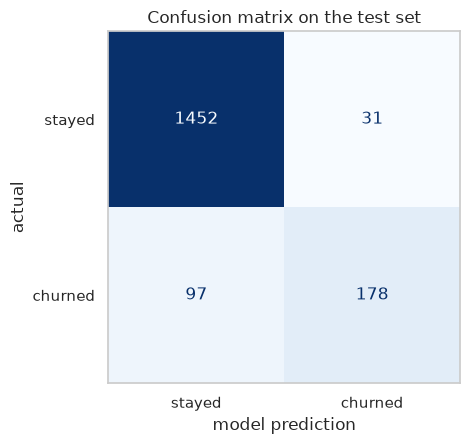

In [97]:
test_confusion = confusion_matrix(y_test, test_prediction)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ConfusionMatrixDisplay(test_confusion, display_labels=['stayed', 'churned']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.grid(False)
ax.set(xlabel='model prediction', ylabel='actual',
       title='Confusion matrix on the test set')
plt.tight_layout()
plt.show()

**What the confusion matrix shows**

- Out of 275 churned customers the model found 178 and missed 97: recall 0.647
- There are only 22 false alarms out of 1483 retained customers
- For "TeleDom" missing a churning customer is costlier than a false alarm, and the threshold of 0.5 is conservative: it buys precision 0.890 at the cost of recall

On the left is the precision-recall curve across all thresholds, with the working threshold of 0.5 marked and a line for the share of churned customers in the test set; on the right are the same metrics as bars. The curve is diagnostic, and the threshold must not be chosen from it, otherwise the test set would turn into yet another validation set

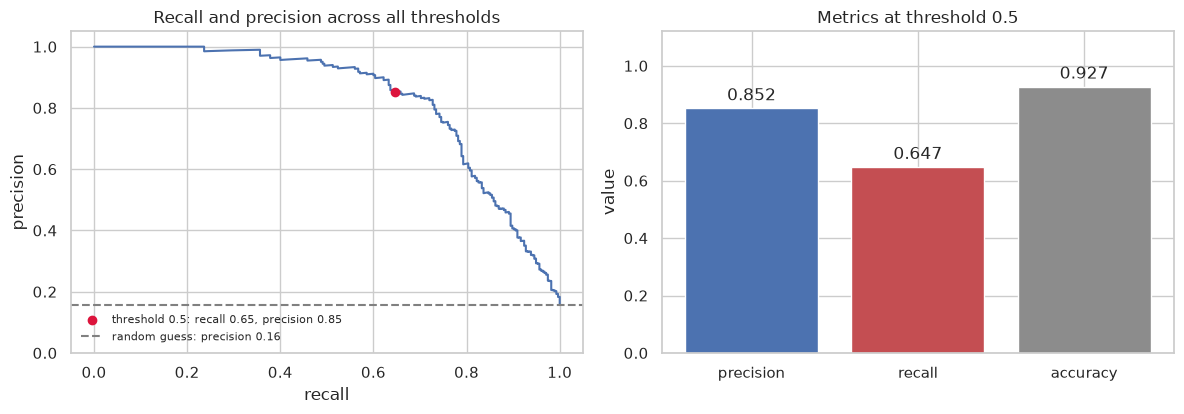

In [98]:
true_negative, false_positive, false_negative, true_positive = test_confusion.ravel()
threshold_precision = true_positive / (true_positive + false_positive)
threshold_recall = true_positive / (true_positive + false_negative)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(recall_curve, precision_curve, color='#4C72B0')
axes[0].scatter(threshold_recall, threshold_precision, color='crimson', zorder=3,
                label=f'threshold 0.5: recall {threshold_recall:.2f}, precision {threshold_precision:.2f}')
axes[0].axhline(y_test.mean(), color='grey', linestyle='--',
                label=f'random guess: precision {y_test.mean():.2f}')
axes[0].set(xlabel='recall', ylabel='precision', ylim=(0, 1.05),
            title='Recall and precision across all thresholds')
axes[0].legend(loc='lower left', fontsize=8, frameon=False)

metric_bars = axes[1].bar(['precision', 'recall', 'accuracy'],
                          [threshold_precision, threshold_recall, test_accuracy],
                          color=['#4C72B0', '#C44E52', '#8C8C8C'])
axes[1].bar_label(metric_bars, fmt='%.3f', padding=3)
axes[1].set(ylim=(0, 1.12), ylabel='value', title='Metrics at threshold 0.5')
plt.tight_layout()
plt.show()

**What recall and precision show**

- The curve keeps precision above 0.85 up to roughly a recall of 0.7, after which it falls off a cliff. The last churning customers come at the cost of an avalanche of false alarms
- The working point at a threshold of 0.5, recall 0.65 at precision 0.89, stands far from random selection with its precision of 0.16
- The threshold for a retention campaign should be chosen by the cost of the errors, not left at the default 0.5

**Interim conclusion for this section**

- The specification threshold was cleared. Test ROC-AUC 0.9306 against the required 0.85, accuracy 0.9323
- A single model went to the test, the single `CatBoost` on native categorical features
- The confusion matrix and the precision-recall curve agree with ROC-AUC: 178 churned customers found out of 275, with 22 false alarms
- The main contribution according to SHAP comes from `life_span`, a retrospective feature, so the number is optimistic relative to live data

<div class="alert alert-success">
<h2> Mentor's comment <a class="tocSkip"> </h2>

<b>Everything is great!👍:</b> a plus for this section, it is clear how the model makes its decision. In the future you could keep only the most significant features and look at the model quality.

## 11. Conclusions

The task: to find customers who are terminating their contract. The data is an export from four Sqlite tables as of February 1, 2020, and the specification requires a ROC-AUC of no less than 0.85 on the test set.

- **Data.** Everything arrived as text; I cast the types to working ones and the column names to snake_case. 11 values of `total_charges` turned out to be placeholder spaces, all of them contracts from the export date; being uninformative, I deleted them, which is 0.16% of the sample. I joined the four tables on `customer_id` with `validate='one_to_one'`, which gave 7032 rows and 24 columns. I extracted the target `churn` from `end_date`: 1101 churned against 5931 retained, 15.7% against 84.3%
- **EDA.** There are no strong associations with the target: the maximum is 0.374 for `life_span` and 0.371 for `contract_duration`. I filtered out `gender`, `dependents` and `internet_service` in 6.3 on the numbers: phik with the target 0.009, 0.049 and 0.056, while the `has_internet` flag is derived from `internet_service` (1.000) and is associated with churn more strongly, 0.114, and `dependents` duplicates `partner` (0.652). Of the four candidates one is non-trivial, `services_count`
- **Models.** Six searches with `OptunaSearchCV` on one-hot, a seventh with `CatBoost` on native categorical features, plus a rank ensemble of the three families. The one-hot waves gave from 0.7960 to 0.8934, `CatBoost` 0.9219, the ensemble 0.8819. The search did not need a weight for the rare class, `auto_class_weights` stayed 'None'
- **Final model.** By the rule fixed before opening the test set, "CatBoost, native categorical features" with a CV ROC-AUC of 0.9219
- **Test.** ROC-AUC 0.9306, accuracy 0.9323, the specification threshold of 0.85 passed with a margin of 0.0806
- **The price of the metric.** The quality rests on `life_span`, which for churned customers is counted up to their termination date, so the offline estimate is optimistic

In [99]:
final_leaderboard = leaderboard[['CV ROC-AUC']].copy()
final_leaderboard['to the 0.85 threshold'] = (0.85 - final_leaderboard['CV ROC-AUC']).round(4)
final_leaderboard['test candidate'] = np.where(final_leaderboard.index == final_model_name,
                                                 'yes, one run', '—')

final_leaderboard.sort_values('CV ROC-AUC', ascending=False).round(4)

,CV ROC-AUC,to the 0.85 threshold,test candidate
model,,,
"CatBoost, native categories",0.9225,-0.0725,"yes, one run"
"HistGB, compact search",0.8886,-0.0386,—
rank ensemble of three families,0.8862,-0.0362,—
"GradientBoosting, wide search",0.8603,-0.0103,—
"neural net, wide search",0.8275,0.0225,—
"neural net, compact search",0.8252,0.0248,—
"tree, compact search",0.7970,0.0530,—
"tree, wide search",0.7966,0.0534,—
DummyClassifier baseline,0.5000,0.3500,—


**Why `life_span` is in the set while contract age measured from the snapshot date is forbidden**

- **The feature is legal.** The specification allows derivatives of `begin_date` that are named explicitly and requires that there be exactly one of them in `X`. There is one in the set, `life_span`: the daily scale is more precise than the monthly one, and `contract_duration` remained only for exploratory analysis
- **The price of the feature.** For a churned customer the period is counted up to `end_date`, from which `churn` was built, while for an active one the boundary is the same for everyone, so the daily scale carries a trace of the churn date itself. The offline estimate is optimistic by that amount
- **The whole class of "from `begin_date` to a fixed snapshot date" is excluded from this work.** `end_date` does not take part in such a formula, but the difference "age from the snapshot − `total_charges / monthly_charges`" equals zero for those who are still paying and is noticeably greater than zero for those who left, that is, it is the target itself bypassing `end_date`. An early version of this work contained exactly such a substitution and was withdrawn as leakage
- **A limitation of the problem statement.** The target is cumulative. `churn` answers the question "was the contract ever terminated before February 1, 2020", so the model describes a historical export rather than predicting the future
- **The order of feature selection.** I did the phik screening and made the decisions about the feature set on the whole merged table, before the split. This order is dictated by the specification itself. In a stricter setting they would be made on the training part only

The main lesson: **a high metric proves nothing by itself; first you have to understand what part of the metric rests on features that reconstruct the business target**

**How to improve the model further**

- **Reformulate the task through cutoff dates and a prediction window.** Several historical dates, only active customers at each of them, features as of the cutoff, and the target "will the customer leave in the next N months". In that setting contract age becomes a legitimate feature
- **Add external data.** Support requests, outages at the address, traffic changes, tariff changes, late payments
- **Calibrate the probabilities,** since computing the profit of a campaign requires not the ordering of customers but the probability itself
- **Choose the threshold by the cost of the errors,** instead of taking 0.5 by default
- **Watch for drift.** Feature distributions, the churn level by cohort, quality on fresh cutoff dates

**Recommendations for "TeleDom"**

Everything below consists of observations about churn that has already happened in a historical export, not a forecast. They should be read as hypotheses to be tested on live data

- **The main risk is not newcomers but the middle of the tenure scale.** Within 7 months 5.0% terminated, at a tenure of 8–18 months 14.3%, and from a year and a half to four and a half years 27%. The longest contracts, 54–76 months, show 5.5%, but that is not veteran loyalty, it is a property of the export: to get into that band a contract had to survive to it. The work should focus on customers of middle tenure
- **The riskiest segment is an adult customer with a large service bundle and a high bill.** At a tenure of 25–48 months, 57.2% of customers with six or seven services left (145 people) and 36.1% of those with four or five (610 people), against 18.7% of those with zero or one. It is the same with money: the top quintile of the monthly payment, above 94.3, gave 26.7% against 9.8% in the bottom one. The hypothesis that "a large bundle retains" was not confirmed, rather the opposite
- **A long contract does not retain by itself.** On the whole, month-to-month customers look more loyal, 10.5% against 21.3% for one-year and 22.6% for two-year contracts, but this is a tenure effect. The median is 12 months against 37 and 55. Within the 1–24 month tenure the picture is the reverse: 7.4% of month-to-month customers against 25.5% of one-year and 39.0% of two-year ones
- **The payment method segments customers, but in an unexpected way.** The mailed check remains the most loyal group even in the slice with a tenure of more than two years: 10.7% against 21.5% for bank transfer, 21.9% for electronic check and 19.8% for credit card. Automatic payment does not work as a barrier; `payment_automatic` was confirmed neither in the screening nor in the tenure breakdown
- **An exact list should not be expected from the model.** The quality rests on the retrospective `life_span`, so the offline estimates (CV 0.9219, test 0.9306) are optimistic: on live data one should expect noticeably lower numbers, and such a model does not produce a "who to send a promo code to" list at an acceptable error cost. The working tool today is marketing activity aimed at the segments described above
- **Start accumulating data for a future model right now.** Monthly snapshots of the customer's state, support requests, incidents, tariff changes. Without history, any model built on such an export will explain the past better than it predicts the future

*Note.* The final metric rests on the daily scale of the contract lifetime: SHAP gives `life_span` 27.8% of the whole explanation, and that scale partly reads off churn that has already happened. This is a limitation of the work, not a finding

<div style="border:solid Chocolate 2px; padding: 40px">

<h2>✔️ Mentor's closing note: <a class="tocSkip"> </h2> 
    
<b>Yaroslav</b>, the work is almost ready, a small revision remains that does not affect the result, you will see my comments above.

Looking forward to your work! :)